# Online Retail Dataset

## Context
You can find it at https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci.

This Online Retail II data set contains all the transactions occurring for a UK-based and registered, non-store online retail between 01/12/2009 and 09/12/2011.The company mainly sells unique all-occasion gift-ware. Many customers of the company are wholesalers.

## Column information
- InvoiceNo: Invoice number. Nominal. A 6-digit integral number uniquely assigned to each transaction. If this code starts with the letter 'c', it indicates a cancellation.
- StockCode: Product (item) code. Nominal. A 5-digit integral number uniquely assigned to each distinct product.
- Description: Product (item) name. Nominal.
- Quantity: The quantities of each product (item) per transaction. Numeric.
- InvoiceDate: Invice date and time. Numeric. The day and time when a transaction was generated.
- UnitPrice: Unit price. Numeric. Product price per unit in sterling (Â£).
- CustomerID: Customer number. Nominal. A 5-digit integral number uniquely assigned to each customer.
- Country: Country name. Nominal. The name of the country where a customer resides.

# Understanding the data

In [ ]:
import pandas as pd

In [ ]:
# Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set file path
path = '/content/drive/MyDrive/newman_data_preprocessing/Superstore Churn Modeling/data/online_retail_II.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
original_df = pd.read_csv(path)

In [ ]:
print("Shape:", original_df.shape)
print("\nColumn names:\n", original_df.columns.tolist())
print("\nData types:\n", original_df.dtypes)
original_df.head(5)

Shape: (1067371, 8)

Column names:
 ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Data types:
 Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


## First Thoughts about this data...
- Why are some customer IDs null? Should we remove them?
- Should we include cancellations?
- Why is invoice date not a date column?
- Why price and quantity column, but no revenue column? Revenue = price * quantity
- There are multiple items on the same invoice --> one row per product per invoice
- Should we group by invoice to avoid repetition on Invoice ID and InvoiceDate?

## Questiont that we are asked:
- What customers did not buy anything in the last month worth of data?
- Can we predict what happens next month?

# Coding

## Basic Cleaning

### Remove null customers

In [ ]:
print("Missing values:\n", original_df.isnull().sum())
print("\nRows before cleaning:", len(original_df))

Missing values:
 Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Rows before cleaning: 1067371


In [ ]:
df = original_df.dropna(subset=['Customer ID']) #drop na on the column that we do not want null values
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


### Remove cancellations

In [ ]:
df[df['Invoice'].astype(str).str.startswith('C')]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [ ]:
df = df[~df['Invoice'].astype(str).str.startswith('C')]

In [ ]:
print(f"Rows after cleaning: {len(df)}")

Rows after cleaning: 805620


### Format dates column

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

/tmp/ipykernel_1631/3633860036.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


### Add revenue column

In [ ]:
df['Revenue'] = df['Quantity'] * df['Price']

/tmp/ipykernel_1631/2072779206.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Revenue'] = df['Quantity'] * df['Price']


## EDA
EDA is not separate from feature engineering — it MOTIVATES it.

### Is there (still) any negative quantity or price?

In [ ]:
import matplotlib.pyplot as plt

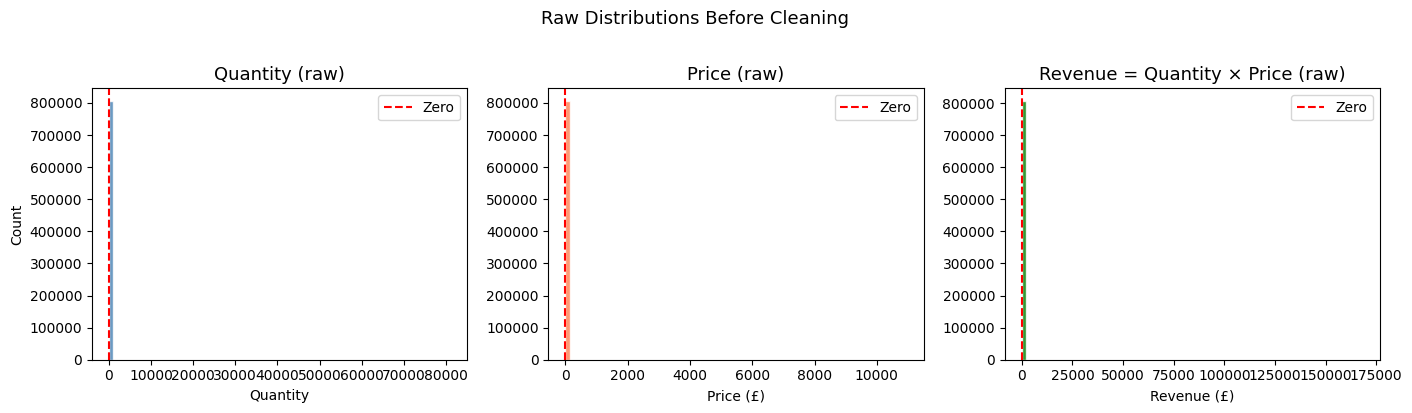

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df['Quantity'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
axes[0].set_title('Quantity (raw)', fontsize=13)
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(df['Price'], bins=80, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
axes[1].set_title('Price (raw)', fontsize=13)
axes[1].set_xlabel('Price (£)')
axes[1].legend()

axes[2].hist((df['Revenue']), bins=80, color='green',
             edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
axes[2].set_title('Revenue = Quantity × Price (raw)', fontsize=13)
axes[2].set_xlabel('Revenue (£)')
axes[2].legend()

plt.suptitle('Raw Distributions Before Cleaning',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
df['Quantity']

,Quantity
0,12
1,12
2,12
3,48
4,24
...,...
1067366,6
1067367,4
1067368,4
1067369,3


In [ ]:
[df['Quantity'] < 1000]

[0          True
 1          True
 2          True
 3          True
 4          True
            ... 
 1067366    True
 1067367    True
 1067368    True
 1067369    True
 1067370    True
 Name: Quantity, Length: 805620, dtype: bool]

In [ ]:
df['Quantity'][df['Quantity'] < 1000]

,Quantity
0,12
1,12
2,12
3,48
4,24
...,...
1067366,6
1067367,4
1067368,4
1067369,3


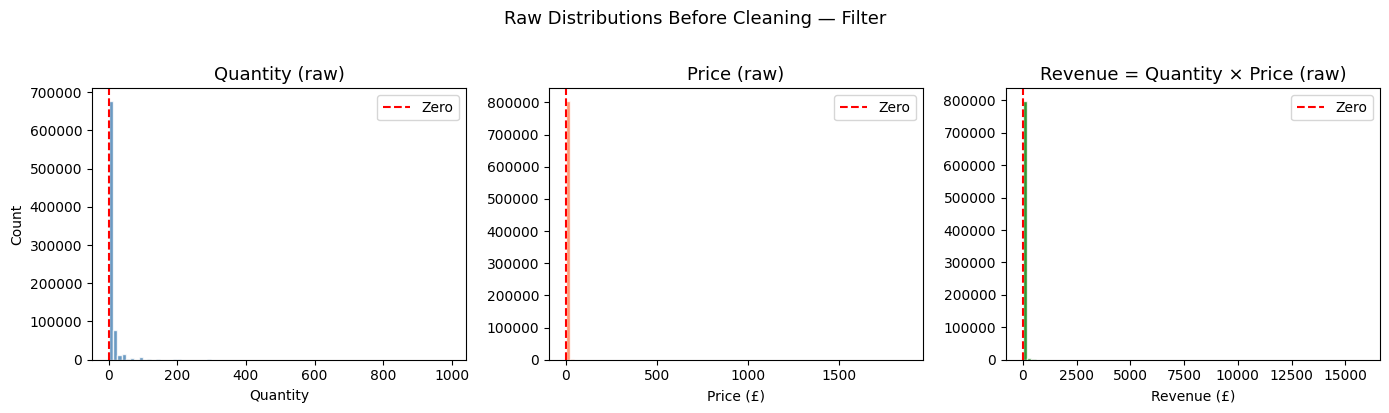

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df['Quantity'][df['Quantity'] < 1000], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
axes[0].set_title('Quantity (raw)', fontsize=13)
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(df['Price'][df['Price'] < 2000], bins=80, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
axes[1].set_title('Price (raw)', fontsize=13)
axes[1].set_xlabel('Price (£)')
axes[1].legend()

axes[2].hist((df['Revenue'][df['Revenue'] < 25000]), bins=80, color='green',
             edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
axes[2].set_title('Revenue = Quantity × Price (raw)', fontsize=13)
axes[2].set_xlabel('Revenue (£)')
axes[2].legend()

plt.suptitle('Raw Distributions Before Cleaning — Filter',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

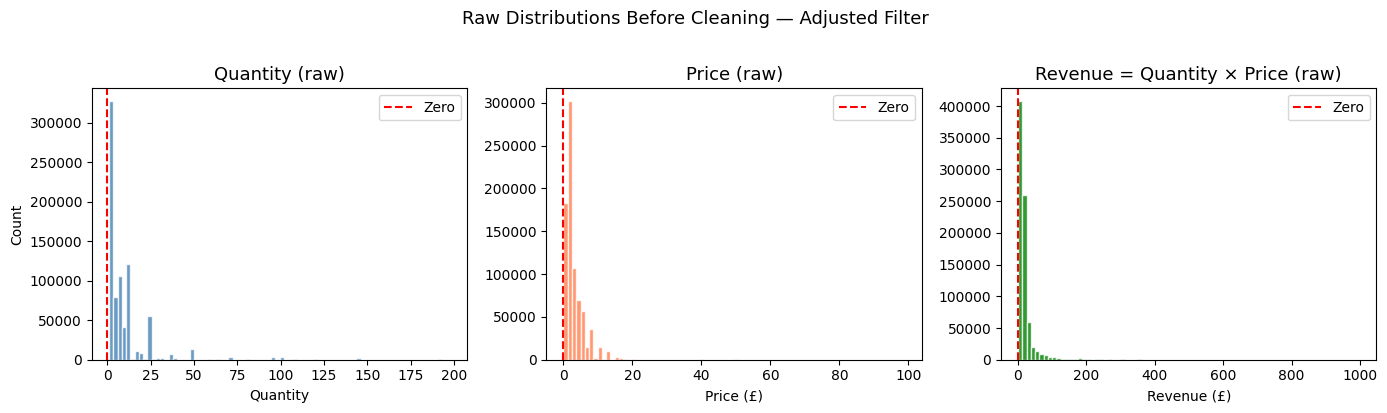

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df['Quantity'][df['Quantity'] < 200], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
axes[0].set_title('Quantity (raw)', fontsize=13)
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(df['Price'][df['Price'] < 100], bins=80, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
axes[1].set_title('Price (raw)', fontsize=13)
axes[1].set_xlabel('Price (£)')
axes[1].legend()

axes[2].hist((df['Revenue'][df['Revenue'] < 1000]), bins=80, color='green',
             edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
axes[2].set_title('Revenue = Quantity × Price (raw)', fontsize=13)
axes[2].set_xlabel('Revenue (£)')
axes[2].legend()

plt.suptitle('Raw Distributions Before Cleaning — Adjusted Filter',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Group by invoice

In [ ]:
df.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [ ]:
df[df.Invoice == 489434]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue


In [ ]:
df[df.Invoice == '489434']

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,39.6
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom,59.5


In [ ]:
invoice_df = df.groupby(['Invoice', 'Customer ID', 'Country', 'InvoiceDate']).agg(
    total_quantity = ('Quantity', 'sum'),
    total_revenue  = ('Revenue', 'sum'),
    num_items      = ('StockCode', 'nunique')   # how many distinct products per invoice
).reset_index()

invoice_df

,Invoice,Customer ID,Country,InvoiceDate,total_quantity,total_revenue,num_items
0,489434,13085.0,United Kingdom,2009-12-01 07:45:00,166,505.30,8
1,489435,13085.0,United Kingdom,2009-12-01 07:46:00,60,145.80,4
2,489436,13078.0,United Kingdom,2009-12-01 09:06:00,193,630.33,19
3,489437,15362.0,United Kingdom,2009-12-01 09:08:00,145,310.75,23
4,489438,18102.0,United Kingdom,2009-12-01 09:24:00,826,2286.24,17
...,...,...,...,...,...,...,...
37034,581583,13777.0,United Kingdom,2011-12-09 12:23:00,76,124.60,2
37035,581584,13777.0,United Kingdom,2011-12-09 12:25:00,120,140.64,2
37036,581585,15804.0,United Kingdom,2011-12-09 12:31:00,278,329.05,21
37037,581586,13113.0,United Kingdom,2011-12-09 12:49:00,66,339.20,4


### Transactions (and invoices) time series analysis

#### Daily

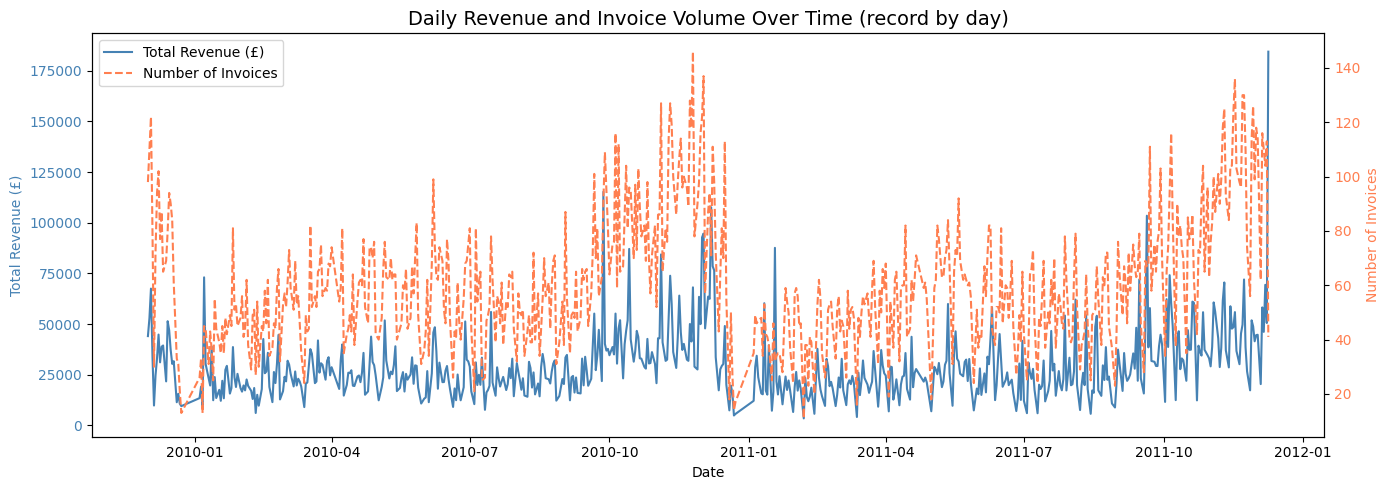

In [ ]:
daily = invoice_df.groupby(invoice_df['InvoiceDate'].dt.date).agg(
    total_revenue  = ('total_revenue', 'sum'),
    num_invoices   = ('Invoice', 'count')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))

# Revenue line — left axis
ax1.plot(daily['InvoiceDate'], daily['total_revenue'],
         color='steelblue', linewidth=1.5, label='Total Revenue (£)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Revenue (£)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Number of invoices — right axis
ax2 = ax1.twinx()
ax2.plot(daily['InvoiceDate'], daily['num_invoices'],
         color='coral', linewidth=1.5, linestyle='--', label='Number of Invoices')
ax2.set_ylabel('Number of Invoices', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('Daily Revenue and Invoice Volume Over Time (record by day)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
def plot_revenue_invoices(data, x_col, title, xlabel, figsize=(14, 4), skip=False):
    fig, ax1 = plt.subplots(figsize=figsize)

    ax1.plot(data[x_col], data['total_revenue'],
             color='steelblue', linewidth=1.5, label='Total Revenue (£)')
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel('Total Revenue (£)', color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')

    ax2 = ax1.twinx()
    ax2.plot(data[x_col], data['num_invoices'],
             color='coral', linewidth=1.5, linestyle='--', label='Number of Invoices')
    ax2.set_ylabel('Number of Invoices', color='coral')
    ax2.tick_params(axis='y', labelcolor='coral')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    ax1.set_title(title, fontsize=13)

    # Only override ticks for categorical/string axes (monthly, weekly with skip)
    if skip:
        ticks = range(0, len(data), 2)
        ax1.set_xticks(ticks)
        ax1.set_xticklabels(data[x_col].iloc[ticks], rotation=45, ha='right')
    else:
        plt.xticks(rotation=45, ha='right')  # let matplotlib place ticks naturally

    plt.tight_layout()
    plt.show()

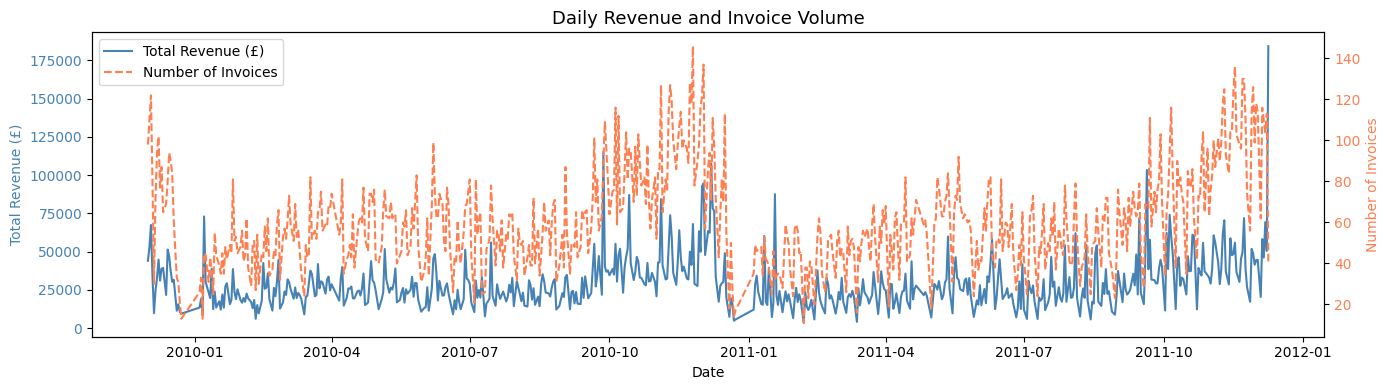

In [ ]:
daily = invoice_df.groupby(invoice_df['InvoiceDate'].dt.date).agg(
    total_revenue = ('total_revenue', 'sum'),
    num_invoices  = ('Invoice', 'count')
).reset_index()

plot_revenue_invoices(daily, 'InvoiceDate',
                      'Daily Revenue and Invoice Volume',
                      'Date')

#### Weekly

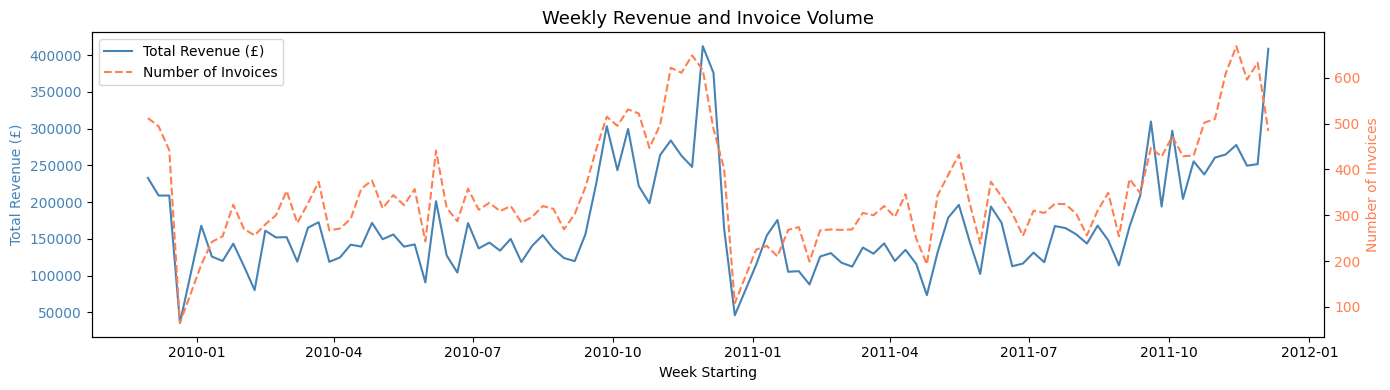

In [ ]:
invoice_df['week'] = invoice_df['InvoiceDate'].dt.to_period('W').dt.start_time

weekly = invoice_df.groupby('week').agg(
    total_revenue = ('total_revenue', 'sum'),
    num_invoices  = ('Invoice', 'count')
).reset_index()

plot_revenue_invoices(weekly, 'week',
                      'Weekly Revenue and Invoice Volume',
                      'Week Starting')

#### Monthly

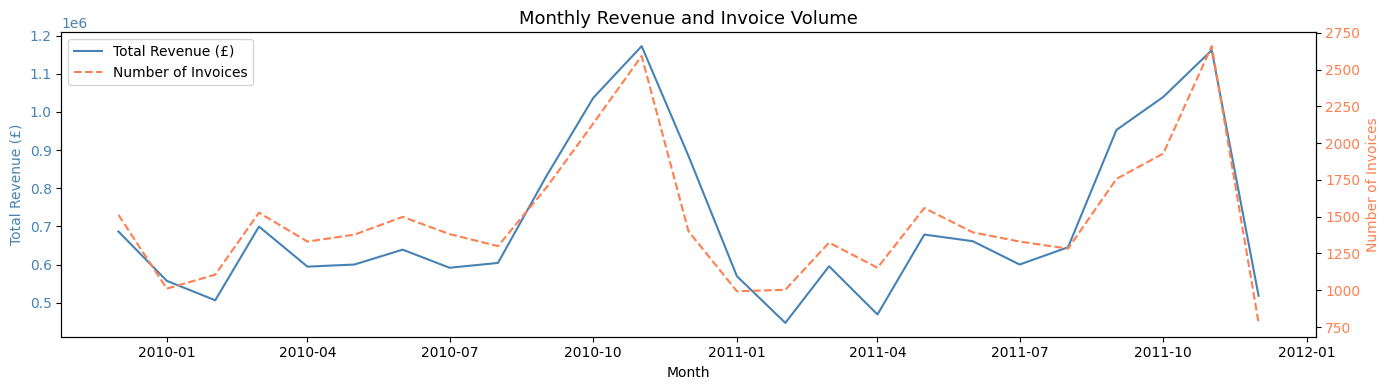

In [ ]:
invoice_df['month'] = invoice_df['InvoiceDate'].dt.to_period('M').dt.start_time

monthly = invoice_df.groupby('month').agg(
    total_revenue = ('total_revenue', 'sum'),
    num_invoices  = ('Invoice', 'count')
).reset_index()

plot_revenue_invoices(monthly, 'month',
                      'Monthly Revenue and Invoice Volume',
                      'Month')

### Extracting datetime components as features

Beyond aggregations, we can extract components FROM the date itself.
These become features that capture cyclical business patterns:
   - Day of month:  are customers more likely to order at month start/end?
   - Weekday:       are orders concentrated on certain days?
   - Day of year:   seasonal position
   - Week of year:  useful for retail seasonality
   - Month:         strongest seasonal signal


In [ ]:
invoice_df['day_of_month']  = invoice_df['InvoiceDate'].dt.day
invoice_df['weekday']       = invoice_df['InvoiceDate'].dt.dayofweek      # 0=Mon, 6=Sun
invoice_df['weekday_name']  = invoice_df['InvoiceDate'].dt.day_name()
invoice_df['day_of_year']   = invoice_df['InvoiceDate'].dt.dayofyear
invoice_df['week_of_year']  = invoice_df['InvoiceDate'].dt.isocalendar().week.astype(int)
invoice_df['month']         = invoice_df['InvoiceDate'].dt.month
invoice_df['hour']          = invoice_df['InvoiceDate'].dt.hour

invoice_df.head(5)

,Invoice,Customer ID,Country,InvoiceDate,total_quantity,total_revenue,num_items,week,month,day_of_month,weekday,weekday_name,day_of_year,week_of_year,hour
0,489434,13085.0,United Kingdom,2009-12-01 07:45:00,166,505.30,8,2009-11-30,12,1,1,Tuesday,335,49,7
1,489435,13085.0,United Kingdom,2009-12-01 07:46:00,60,145.80,4,2009-11-30,12,1,1,Tuesday,335,49,7
2,489436,13078.0,United Kingdom,2009-12-01 09:06:00,193,630.33,19,2009-11-30,12,1,1,Tuesday,335,49,9
3,489437,15362.0,United Kingdom,2009-12-01 09:08:00,145,310.75,23,2009-11-30,12,1,1,Tuesday,335,49,9
4,489438,18102.0,United Kingdom,2009-12-01 09:24:00,826,2286.24,17,2009-11-30,12,1,1,Tuesday,335,49,9


In [ ]:
# fig, axes = plt.subplots(3, 3, figsize=(15, 11))

# # Day of month
# axes[0,0].bar(range(1, 32),
#               invoice_df.groupby('day_of_month')['Invoice'].count(),
#               color='steelblue', edgecolor='white', alpha=0.8)
# axes[0,0].set_title('Invoices by Day of Month', fontsize=12)
# axes[0,0].set_xlabel('Day of Month')
# axes[0,0].set_ylabel('Number of Invoices')

# # Weekday
# wd_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
# wd_counts = invoice_df.groupby('weekday_name')['Invoice'].count().reindex(wd_order)
# axes[0,1].bar(wd_order, wd_counts,
#               color='coral', edgecolor='white', alpha=0.8)
# axes[0,1].set_title('Invoices by Weekday', fontsize=12)
# axes[0,1].set_xlabel('Weekday')
# axes[0,1].set_ylabel('Number of Invoices')
# plt.setp(axes[0,1].xaxis.get_majorticklabels(), rotation=30, ha='right')

# # Day of year
# axes[0,2].plot(invoice_df.groupby('day_of_year')['Invoice'].count(),
#                color='green', linewidth=1)
# axes[0,2].set_title('Invoices by Day of Year', fontsize=12)
# axes[0,2].set_xlabel('Day of Year')
# axes[0,2].set_ylabel('Number of Invoices')

# # Week of year
# axes[1,0].bar(invoice_df.groupby('week_of_year')['Invoice'].count().index,
#               invoice_df.groupby('week_of_year')['Invoice'].count().values,
#               color='purple', edgecolor='white', alpha=0.8)
# axes[1,0].set_title('Invoices by Week of Year', fontsize=12)
# axes[1,0].set_xlabel('Week of Year')
# axes[1,0].set_ylabel('Number of Invoices')

# # Month
# axes[1,1].bar(range(1, 13),
#               invoice_df.groupby('month')['Invoice'].count(),
#               color='steelblue', edgecolor='white', alpha=0.8)
# axes[1,1].set_title('Invoices by Month', fontsize=12)
# axes[1,1].set_xlabel('Month')
# axes[1,1].set_ylabel('Number of Invoices')
# axes[1,1].set_xticks(range(1, 13))
# axes[1,1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
#                             'Jul','Aug','Sep','Oct','Nov','Dec'])
# plt.setp(axes[1,1].xaxis.get_majorticklabels(), rotation=30, ha='right')

# # Average revenue by weekday
# wd_rev = invoice_df.groupby('weekday_name')['total_revenue'].mean().reindex(wd_order)
# axes[1,2].bar(wd_order, wd_rev, color='coral', edgecolor='white', alpha=0.8)
# axes[1,2].set_title('Avg Revenue by Weekday', fontsize=12)
# axes[1,2].set_xlabel('Weekday')
# axes[1,2].set_ylabel('Avg Revenue (£)')
# plt.setp(axes[1,2].xaxis.get_majorticklabels(), rotation=30, ha='right')

# # Hour of day — invoice count
# axes[2,0].bar(range(24),
#               invoice_df.groupby('hour')['Invoice'].count(),
#               color='steelblue', edgecolor='white', alpha=0.8)
# axes[2,0].set_title('Invoices by Hour of Day', fontsize=12)
# axes[2,0].set_xlabel('Hour (0 = midnight)')
# axes[2,0].set_ylabel('Number of Invoices')
# axes[2,0].set_xticks(range(0, 24, 2))

# # Hour of day — average revenue
# axes[2,1].bar(range(24),
#               invoice_df.groupby('hour')['total_revenue'].mean(),
#               color='purple', edgecolor='white', alpha=0.8)
# axes[2,1].set_title('Avg Revenue by Hour of Day', fontsize=12)
# axes[2,1].set_xlabel('Hour (0 = midnight)')
# axes[2,1].set_ylabel('Avg Revenue (£)')
# axes[2,1].set_xticks(range(0, 24, 2))

# # Hide unused subplot
# axes[2,2].set_visible(False)

# plt.suptitle('DateTime Component Distributions', fontsize=14, y=1.01)
# plt.tight_layout()
# plt.show()


Not all 24 hours appear on the data! Let's fix it...

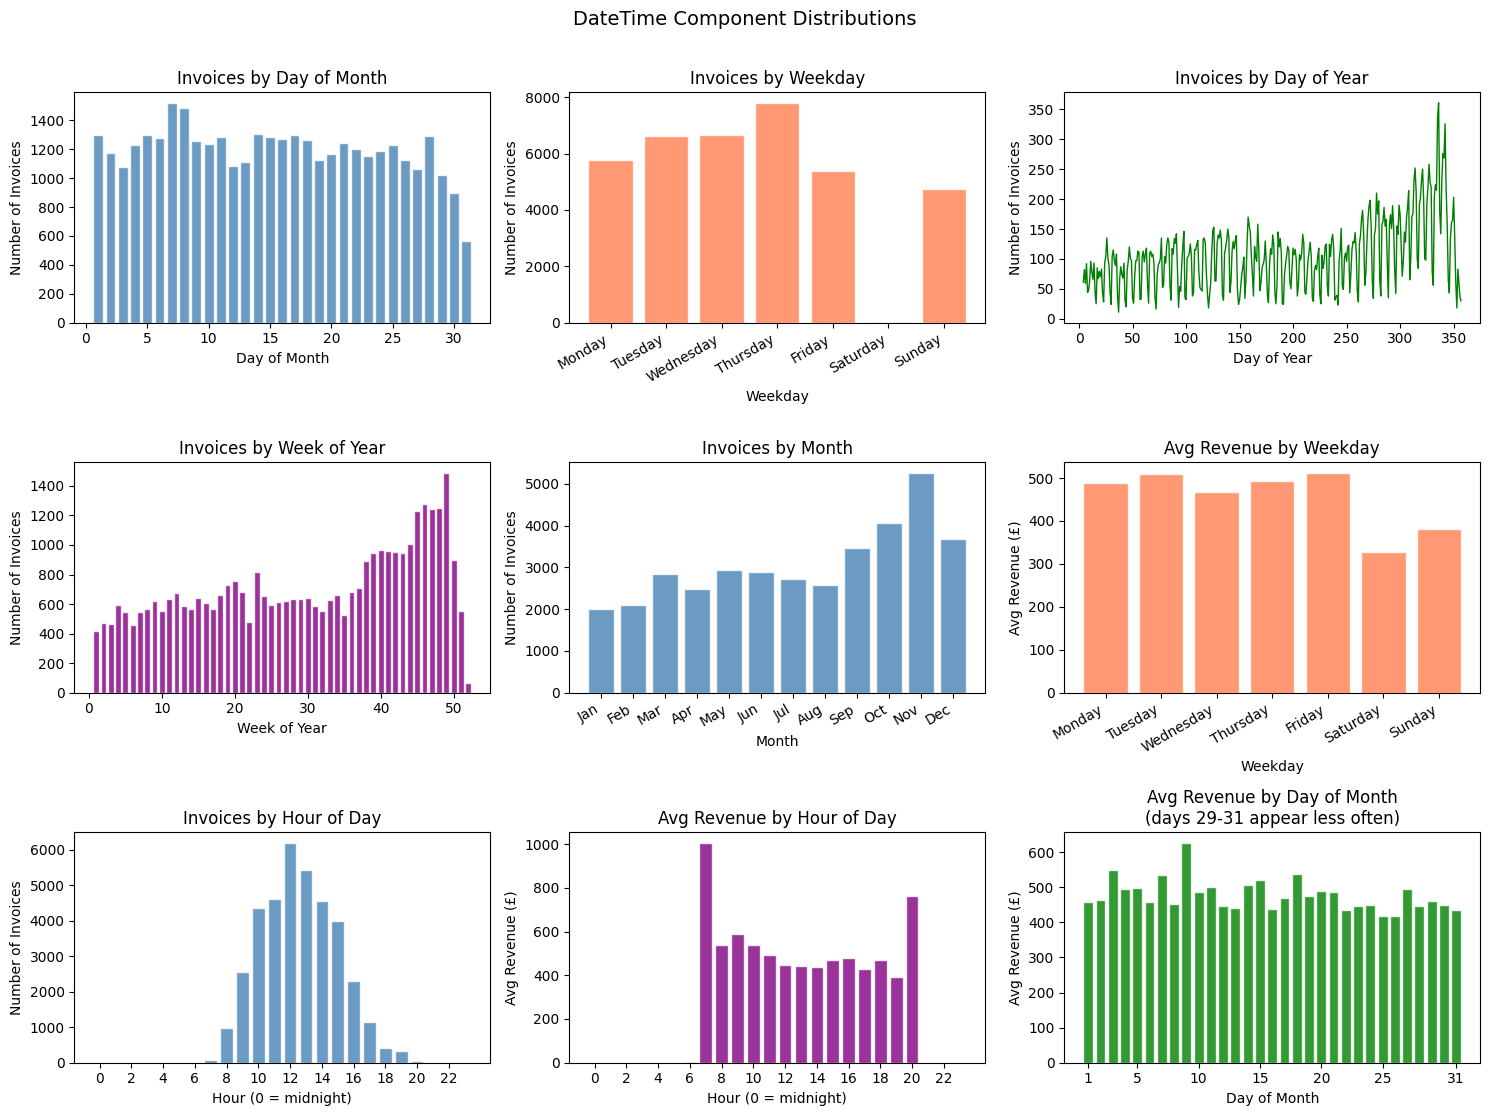

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))

# Day of month
axes[0,0].bar(range(1, 32),
              invoice_df.groupby('day_of_month')['Invoice'].count(),
              color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].set_title('Invoices by Day of Month', fontsize=12)
axes[0,0].set_xlabel('Day of Month')
axes[0,0].set_ylabel('Number of Invoices')

# Weekday
wd_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
wd_counts = invoice_df.groupby('weekday_name')['Invoice'].count().reindex(wd_order)
axes[0,1].bar(wd_order, wd_counts,
              color='coral', edgecolor='white', alpha=0.8)
axes[0,1].set_title('Invoices by Weekday', fontsize=12)
axes[0,1].set_xlabel('Weekday')
axes[0,1].set_ylabel('Number of Invoices')
plt.setp(axes[0,1].xaxis.get_majorticklabels(), rotation=30, ha='right')

# Day of year
axes[0,2].plot(invoice_df.groupby('day_of_year')['Invoice'].count(),
               color='green', linewidth=1)
axes[0,2].set_title('Invoices by Day of Year', fontsize=12)
axes[0,2].set_xlabel('Day of Year')
axes[0,2].set_ylabel('Number of Invoices')

# Week of year
axes[1,0].bar(invoice_df.groupby('week_of_year')['Invoice'].count().index,
              invoice_df.groupby('week_of_year')['Invoice'].count().values,
              color='purple', edgecolor='white', alpha=0.8)
axes[1,0].set_title('Invoices by Week of Year', fontsize=12)
axes[1,0].set_xlabel('Week of Year')
axes[1,0].set_ylabel('Number of Invoices')

# Month
axes[1,1].bar(range(1, 13),
              invoice_df.groupby('month')['Invoice'].count(),
              color='steelblue', edgecolor='white', alpha=0.8)
axes[1,1].set_title('Invoices by Month', fontsize=12)
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Number of Invoices')
axes[1,1].set_xticks(range(1, 13))
axes[1,1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                            'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.setp(axes[1,1].xaxis.get_majorticklabels(), rotation=30, ha='right')

# Average revenue by weekday
wd_rev = invoice_df.groupby('weekday_name')['total_revenue'].mean().reindex(wd_order)
axes[1,2].bar(wd_order, wd_rev, color='coral', edgecolor='white', alpha=0.8)
axes[1,2].set_title('Avg Revenue by Weekday', fontsize=12)
axes[1,2].set_xlabel('Weekday')
axes[1,2].set_ylabel('Avg Revenue (£)')
plt.setp(axes[1,2].xaxis.get_majorticklabels(), rotation=30, ha='right')

# Hour of day — reindex to all 24 hours so missing hours show as 0
hour_count = (invoice_df.groupby('hour')['Invoice'].count()
                        .reindex(range(24), fill_value=0))
hour_rev   = (invoice_df.groupby('hour')['total_revenue'].mean()
                        .reindex(range(24), fill_value=0))

axes[2,0].bar(range(24), hour_count,
              color='steelblue', edgecolor='white', alpha=0.8)
axes[2,0].set_title('Invoices by Hour of Day', fontsize=12)
axes[2,0].set_xlabel('Hour (0 = midnight)')
axes[2,0].set_ylabel('Number of Invoices')
axes[2,0].set_xticks(range(0, 24, 2))

axes[2,1].bar(range(24), hour_rev,
              color='purple', edgecolor='white', alpha=0.8)
axes[2,1].set_title('Avg Revenue by Hour of Day', fontsize=12)
axes[2,1].set_xlabel('Hour (0 = midnight)')
axes[2,1].set_ylabel('Avg Revenue (£)')
axes[2,1].set_xticks(range(0, 24, 2))

# Avg revenue by day of month — reindex to all 31 days, fill missing with 0
dom_rev = (invoice_df.groupby('day_of_month')['total_revenue'].mean()
                     .reindex(range(1, 32), fill_value=0))

axes[2,2].bar(range(1, 32), dom_rev,
              color='green', edgecolor='white', alpha=0.8)
axes[2,2].set_title('Avg Revenue by Day of Month\n(days 29-31 appear less often)', fontsize=12)
axes[2,2].set_xlabel('Day of Month')
axes[2,2].set_ylabel('Avg Revenue (£)')
axes[2,2].set_xticks([1, 5, 10, 15, 20, 25, 31])

plt.suptitle('DateTime Component Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

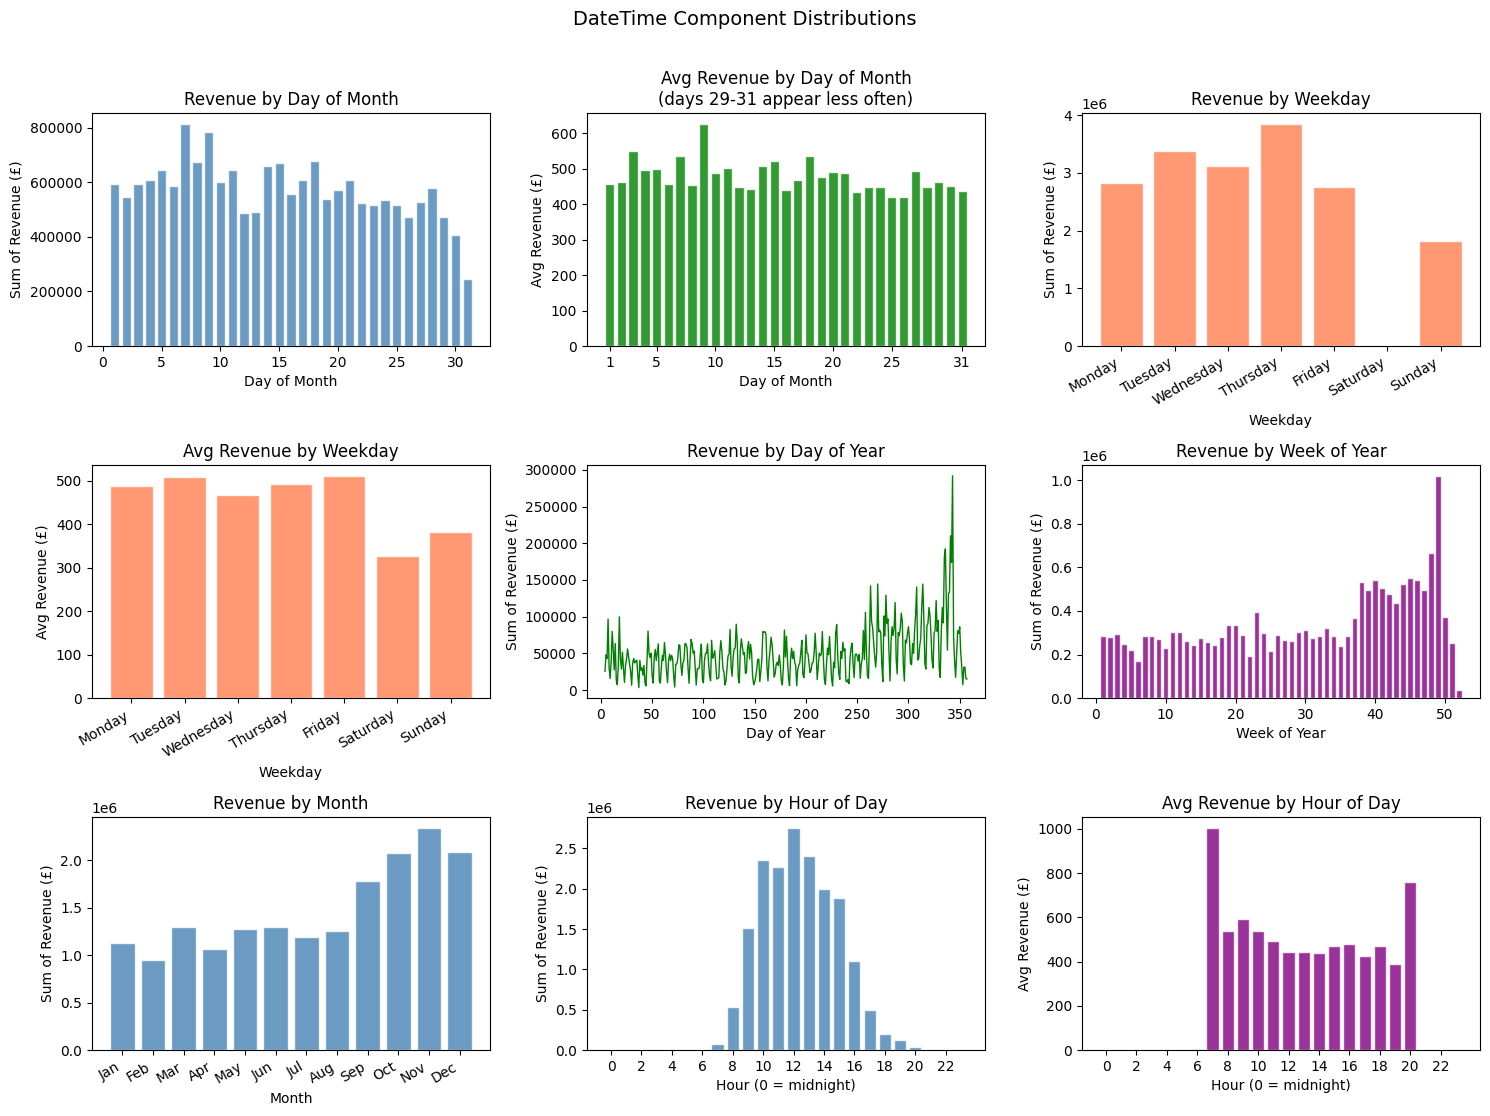

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))

# Day of month
axes[0,0].bar(range(1, 32),
              invoice_df.groupby('day_of_month')['total_revenue'].sum(),
              color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].set_title('Revenue by Day of Month', fontsize=12)
axes[0,0].set_xlabel('Day of Month')
axes[0,0].set_ylabel('Sum of Revenue (£)')

# Avg revenue by day of month — reindex to all 31 days, fill missing with 0
dom_rev = (invoice_df.groupby('day_of_month')['total_revenue'].mean()
                     .reindex(range(1, 32), fill_value=0))

axes[0,1].bar(range(1, 32), dom_rev,
              color='green', edgecolor='white', alpha=0.8)
axes[0,1].set_title('Avg Revenue by Day of Month\n(days 29-31 appear less often)', fontsize=12)
axes[0,1].set_xlabel('Day of Month')
axes[0,1].set_ylabel('Avg Revenue (£)')
axes[0,1].set_xticks([1, 5, 10, 15, 20, 25, 31])

# Weekday
wd_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
wd_counts = invoice_df.groupby('weekday_name')['total_revenue'].sum().reindex(wd_order)
axes[0,2].bar(wd_order, wd_counts,
              color='coral', edgecolor='white', alpha=0.8)
axes[0,2].set_title('Revenue by Weekday', fontsize=12)
axes[0,2].set_xlabel('Weekday')
axes[0,2].set_ylabel('Sum of Revenue (£)')
plt.setp(axes[0,2].xaxis.get_majorticklabels(), rotation=30, ha='right')

# Average revenue by weekday
wd_rev = invoice_df.groupby('weekday_name')['total_revenue'].mean().reindex(wd_order)
axes[1,0].bar(wd_order, wd_rev, color='coral', edgecolor='white', alpha=0.8)
axes[1,0].set_title('Avg Revenue by Weekday', fontsize=12)
axes[1,0].set_xlabel('Weekday')
axes[1,0].set_ylabel('Avg Revenue (£)')
plt.setp(axes[1,0].xaxis.get_majorticklabels(), rotation=30, ha='right')

# Day of year
axes[1,1].plot(invoice_df.groupby('day_of_year')['total_revenue'].sum(),
               color='green', linewidth=1)
axes[1,1].set_title('Revenue by Day of Year', fontsize=12)
axes[1,1].set_xlabel('Day of Year')
axes[1,1].set_ylabel('Sum of Revenue (£)')

# Week of year
axes[1,2].bar(invoice_df.groupby('week_of_year')['total_revenue'].sum().index,
              invoice_df.groupby('week_of_year')['total_revenue'].sum().values,
              color='purple', edgecolor='white', alpha=0.8)
axes[1,2].set_title('Revenue by Week of Year', fontsize=12)
axes[1,2].set_xlabel('Week of Year')
axes[1,2].set_ylabel('Sum of Revenue (£)')

# Month
axes[2,0].bar(range(1, 13),
              invoice_df.groupby('month')['total_revenue'].sum(),
              color='steelblue', edgecolor='white', alpha=0.8)
axes[2,0].set_title('Revenue by Month', fontsize=12)
axes[2,0].set_xlabel('Month')
axes[2,0].set_ylabel('Sum of Revenue (£)')
axes[2,0].set_xticks(range(1, 13))
axes[2,0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                            'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.setp(axes[2,0].xaxis.get_majorticklabels(), rotation=30, ha='right')



# Hour of day — reindex to all 24 hours so missing hours show as 0
hour_count = (invoice_df.groupby('hour')['total_revenue'].sum()
                        .reindex(range(24), fill_value=0))
hour_rev   = (invoice_df.groupby('hour')['total_revenue'].mean()
                        .reindex(range(24), fill_value=0))

axes[2,1].bar(range(24), hour_count,
              color='steelblue', edgecolor='white', alpha=0.8)
axes[2,1].set_title('Revenue by Hour of Day', fontsize=12)
axes[2,1].set_xlabel('Hour (0 = midnight)')
axes[2,1].set_ylabel('Sum of Revenue (£)')
axes[2,1].set_xticks(range(0, 24, 2))

axes[2,2].bar(range(24), hour_rev,
              color='purple', edgecolor='white', alpha=0.8)
axes[2,2].set_title('Avg Revenue by Hour of Day', fontsize=12)
axes[2,2].set_xlabel('Hour (0 = midnight)')
axes[2,2].set_ylabel('Avg Revenue (£)')
axes[2,2].set_xticks(range(0, 24, 2))



plt.suptitle('DateTime Component Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
invoice_df['year_month']    = invoice_df['InvoiceDate'].dt.to_period('M')
invoice_df.groupby('year_month').count()

,Invoice,Customer ID,Country,InvoiceDate,total_quantity,total_revenue,num_items,week,month,day_of_month,weekday,weekday_name,day_of_year,week_of_year,hour
year_month,,,,,,,,,,,,,,,
2009-12,1513,1513,1513,1513,1513,1513,1513,1513,1513,1513,1513,1513,1513,1513,1513
2010-01,1011,1011,1011,1011,1011,1011,1011,1011,1011,1011,1011,1011,1011,1011,1011
2010-02,1106,1106,1106,1106,1106,1106,1106,1106,1106,1106,1106,1106,1106,1106,1106
2010-03,1528,1528,1528,1528,1528,1528,1528,1528,1528,1528,1528,1528,1528,1528,1528
2010-04,1331,1331,1331,1331,1331,1331,1331,1331,1331,1331,1331,1331,1331,1331,1331
2010-05,1378,1378,1378,1378,1378,1378,1378,1378,1378,1378,1378,1378,1378,1378,1378
2010-06,1499,1499,1499,1499,1499,1499,1499,1499,1499,1499,1499,1499,1499,1499,1499
2010-07,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382
2010-08,1300,1300,1300,1300,1300,1300,1300,1300,1300,1300,1300,1300,1300,1300,1300


In [ ]:
monthly = invoice_df.groupby('year_month').agg(
    total_revenue = ('total_revenue', 'sum'),
    num_invoices  = ('Invoice', 'count')
).reset_index()

# plot_revenue_invoices(monthly, 'year_month',
#                       'Monthly Revenue and Invoice Volume',
#                       'Month')

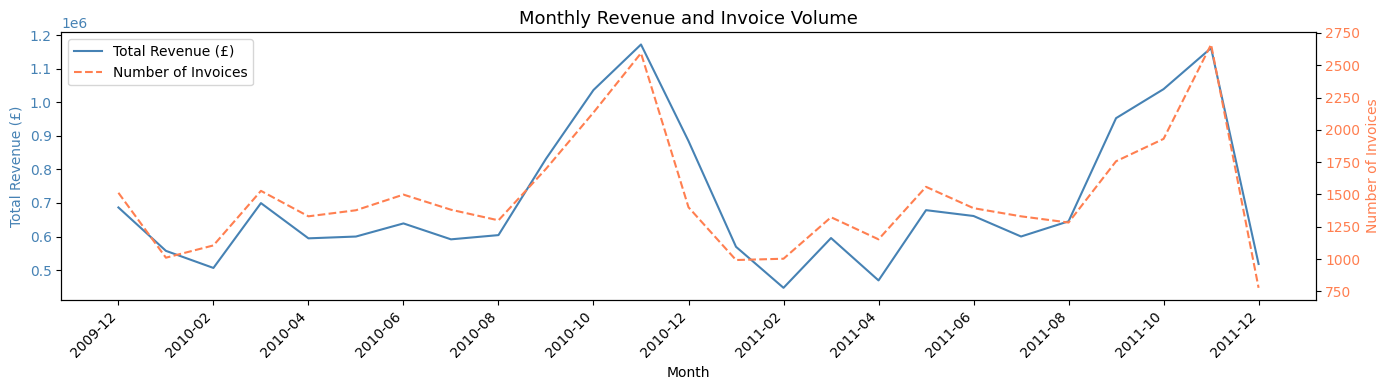

In [ ]:
monthly = invoice_df.groupby('year_month').agg(
    total_revenue = ('total_revenue', 'sum'),
    num_invoices  = ('Invoice', 'count')
).reset_index()

monthly['year_month'] = monthly['year_month'].astype('str')
plot_revenue_invoices(monthly, 'year_month',
                      'Monthly Revenue and Invoice Volume',
                      'Month', skip =True)


In [ ]:
invoice_df = invoice_df[invoice_df.year_month != '2011-12']

In [ ]:
import numpy as np
invoice_df['train_test_flag'] = np.where(
    invoice_df['year_month'] == '2011-11',
    'test',
    'train'
)
invoice_df

/tmp/ipykernel_1631/2351420961.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  invoice_df['train_test_flag'] = np.where(


,Invoice,Customer ID,Country,InvoiceDate,total_quantity,total_revenue,num_items,week,month,day_of_month,weekday,weekday_name,day_of_year,week_of_year,hour,year_month,train_test_flag
0,489434,13085.0,United Kingdom,2009-12-01 07:45:00,166,505.30,8,2009-11-30,12,1,1,Tuesday,335,49,7,2009-12,train
1,489435,13085.0,United Kingdom,2009-12-01 07:46:00,60,145.80,4,2009-11-30,12,1,1,Tuesday,335,49,7,2009-12,train
2,489436,13078.0,United Kingdom,2009-12-01 09:06:00,193,630.33,19,2009-11-30,12,1,1,Tuesday,335,49,9,2009-12,train
3,489437,15362.0,United Kingdom,2009-12-01 09:08:00,145,310.75,23,2009-11-30,12,1,1,Tuesday,335,49,9,2009-12,train
4,489438,18102.0,United Kingdom,2009-12-01 09:24:00,826,2286.24,17,2009-11-30,12,1,1,Tuesday,335,49,9,2009-12,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36256,579868,15544.0,United Kingdom,2011-11-30 16:43:00,406,328.32,22,2011-11-28,11,30,2,Wednesday,334,48,16,2011-11,test
36257,579870,12437.0,France,2011-11-30 16:47:00,99,292.41,14,2011-11-28,11,30,2,Wednesday,334,48,16,2011-11,test
36258,579872,14085.0,United Kingdom,2011-11-30 16:54:00,239,278.82,17,2011-11-28,11,30,2,Wednesday,334,48,16,2011-11,test
36259,579881,12429.0,Denmark,2011-11-30 17:22:00,512,905.52,27,2011-11-28,11,30,2,Wednesday,334,48,17,2011-11,test


# Second Part

Our Question:
- **What customers did not buy anything in the last month worth of data?**
- **Can we predict it?**

## Initial Coding

### Customer-Month Grid

Find all combinations of year_month and customer:
- Find all months
- Find all customers
- Outer join to have one row for each combination of month and customer

In [ ]:
all_customers = invoice_df['Customer ID'].unique()

all_year_months = invoice_df['year_month'].unique()

print("Customers: ", all_customers)
print("Year-Months: ", all_year_months)

Customers:  [13085. 13078. 15362. ... 12966. 15060. 17911.]
Year-Months:  <PeriodArray>
['2009-12', '2010-01', '2010-02', '2010-03', '2010-04', '2010-05', '2010-06',
 '2010-07', '2010-08', '2010-09', '2010-10', '2010-11', '2010-12', '2011-01',
 '2011-02', '2011-03', '2011-04', '2011-05', '2011-06', '2011-07', '2011-08',
 '2011-09', '2011-10', '2011-11']
Length: 24, dtype: period[M]


In [ ]:
from itertools import product

customer_month_grid = pd.DataFrame(
    list(product(all_customers, all_year_months)),
    columns=['Customer ID', 'year_month']
)
customer_month_grid

,Customer ID,year_month
0,13085.0,2009-12
1,13085.0,2010-01
2,13085.0,2010-02
3,13085.0,2010-03
4,13085.0,2010-04
...,...,...
140467,17911.0,2011-07
140468,17911.0,2011-08
140469,17911.0,2011-09
140470,17911.0,2011-10


### Customer-Month Summary by Month
Columns created:
- Total revenue
- Count of invoices
- Average revenue size
- Number of unique products

In [ ]:
monthly_agg = invoice_df.groupby(['Customer ID', 'year_month','train_test_flag']).agg(
    total_revenue    = ('total_revenue', 'sum'),
    num_invoices     = ('Invoice', 'count'),
    avg_basket_size  = ('total_revenue', 'mean'),
    total_items      = ('total_quantity', 'sum'),
    unique_products  = ('num_items', 'sum'),
).reset_index()
monthly_agg.head(5)

,Customer ID,year_month,train_test_flag,total_revenue,num_invoices,avg_basket_size,total_items,unique_products
0,12346.0,2009-12,train,113.50,5,22.70,26,5
1,12346.0,2010-01,train,90.00,4,22.50,20,4
2,12346.0,2010-03,train,27.05,1,27.05,5,5
3,12346.0,2010-06,train,142.31,1,142.31,19,19
4,12346.0,2011-01,train,77183.60,1,77183.60,74215,1


In [ ]:
monthly_agg[monthly_agg['Customer ID'] == 13085]

,Customer ID,year_month,train_test_flag,total_revenue,num_invoices,avg_basket_size,total_items,unique_products
3099,13085.0,2009-12,train,1096.80,4,274.20,376,26
3100,13085.0,2010-01,train,920.40,2,460.20,352,36
3101,13085.0,2011-02,train,278.10,1,278.10,172,13
3102,13085.0,2011-07,train,137.98,1,137.98,44,9


### Merge monthly aggregations and customer-month grid

In [ ]:
customer_month_grid.merge(monthly_agg, on=['Customer ID', 'year_month'], how='left')

,Customer ID,year_month,train_test_flag,total_revenue,num_invoices,avg_basket_size,total_items,unique_products
0,13085.0,2009-12,train,1096.80,4.0,274.20,376.0,26.0
1,13085.0,2010-01,train,920.40,2.0,460.20,352.0,36.0
2,13085.0,2010-02,NaN,NaN,NaN,NaN,NaN,NaN
3,13085.0,2010-03,NaN,NaN,NaN,NaN,NaN,NaN
4,13085.0,2010-04,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
140467,17911.0,2011-07,NaN,NaN,NaN,NaN,NaN,NaN
140468,17911.0,2011-08,NaN,NaN,NaN,NaN,NaN,NaN
140469,17911.0,2011-09,NaN,NaN,NaN,NaN,NaN,NaN
140470,17911.0,2011-10,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
final_df = customer_month_grid.merge(monthly_agg, on=['Customer ID', 'year_month'], how='left')
final_df = final_df.fillna(0)

final_df['train_test_flag'] = np.where(
    final_df['year_month'] == '2011-11',
    'test',
    'train'
)

final_df

,Customer ID,year_month,train_test_flag,total_revenue,num_invoices,avg_basket_size,total_items,unique_products
0,13085.0,2009-12,train,1096.80,4.0,274.20,376.0,26.0
1,13085.0,2010-01,train,920.40,2.0,460.20,352.0,36.0
2,13085.0,2010-02,train,0.00,0.0,0.00,0.0,0.0
3,13085.0,2010-03,train,0.00,0.0,0.00,0.0,0.0
4,13085.0,2010-04,train,0.00,0.0,0.00,0.0,0.0
...,...,...,...,...,...,...,...,...
140467,17911.0,2011-07,train,0.00,0.0,0.00,0.0,0.0
140468,17911.0,2011-08,train,0.00,0.0,0.00,0.0,0.0
140469,17911.0,2011-09,train,0.00,0.0,0.00,0.0,0.0
140470,17911.0,2011-10,train,0.00,0.0,0.00,0.0,0.0


### Define churn label and create test and train datasets

In [ ]:
final_df['churned'] = (final_df['num_invoices'] == 0).astype(int)
final_df

,Customer ID,year_month,train_test_flag,total_revenue,num_invoices,avg_basket_size,total_items,unique_products,churned
0,13085.0,2009-12,train,1096.80,4.0,274.20,376.0,26.0,0
1,13085.0,2010-01,train,920.40,2.0,460.20,352.0,36.0,0
2,13085.0,2010-02,train,0.00,0.0,0.00,0.0,0.0,1
3,13085.0,2010-03,train,0.00,0.0,0.00,0.0,0.0,1
4,13085.0,2010-04,train,0.00,0.0,0.00,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...
140467,17911.0,2011-07,train,0.00,0.0,0.00,0.0,0.0,1
140468,17911.0,2011-08,train,0.00,0.0,0.00,0.0,0.0,1
140469,17911.0,2011-09,train,0.00,0.0,0.00,0.0,0.0,1
140470,17911.0,2011-10,train,0.00,0.0,0.00,0.0,0.0,1


In [ ]:
train_df = final_df[final_df.train_test_flag == 'train'].drop('train_test_flag',axis=1)
test_df = final_df[final_df.train_test_flag == 'test'].drop('train_test_flag',axis=1)

In [ ]:
test_df.head(5)

,Customer ID,year_month,total_revenue,num_invoices,avg_basket_size,total_items,unique_products,churned
23,13085.0,2011-11,0.00,0.0,0.0000,0.0,0.0,1
47,13078.0,2011-11,1963.93,4.0,490.9825,1109.0,36.0,0
71,15362.0,2011-11,0.00,0.0,0.0000,0.0,0.0,1
95,18102.0,2011-11,15331.08,6.0,2555.1800,8186.0,47.0,0
119,12682.0,2011-11,2425.80,6.0,404.3000,1178.0,82.0,0


In [ ]:
train_df.head(5)

,Customer ID,year_month,total_revenue,num_invoices,avg_basket_size,total_items,unique_products,churned
0,13085.0,2009-12,1096.8,4.0,274.2,376.0,26.0,0
1,13085.0,2010-01,920.4,2.0,460.2,352.0,36.0,0
2,13085.0,2010-02,0.0,0.0,0.0,0.0,0.0,1
3,13085.0,2010-03,0.0,0.0,0.0,0.0,0.0,1
4,13085.0,2010-04,0.0,0.0,0.0,0.0,0.0,1


## Further Analysis

We need to solve two problems with our current dataset:

**1. Already-churned customers:** our grid includes every customer in every month,
even customers who last bought in 2009. Predicting those is pointless —
we want to flag customers who were *just active* but are now at risk.

**2. Data leakage:** our current features come from the *same month* as the label.
In real deployment, when we want to predict November, we don't have November's data yet.
Features must come from *before* the prediction month.



**Our approach:**
- Lookback window = 1 month (features from month M-1 predict label in month M)
- Active = customer placed at least one order in month M-1
- This means every row in our final dataset represents a customer who bought
  last month — and we're asking: did they come back this month?

In [ ]:
final_df.head(5)

,Customer ID,year_month,train_test_flag,total_revenue,num_invoices,avg_basket_size,total_items,unique_products,churned
0,13085.0,2009-12,train,1096.8,4.0,274.2,376.0,26.0,0
1,13085.0,2010-01,train,920.4,2.0,460.2,352.0,36.0,0
2,13085.0,2010-02,train,0.0,0.0,0.0,0.0,0.0,1
3,13085.0,2010-03,train,0.0,0.0,0.0,0.0,0.0,1
4,13085.0,2010-04,train,0.0,0.0,0.0,0.0,0.0,1


In [ ]:
final_df

,Customer ID,year_month,train_test_flag,total_revenue,num_invoices,avg_basket_size,total_items,unique_products,churned
0,13085.0,2009-12,train,1096.80,4.0,274.20,376.0,26.0,0
1,13085.0,2010-01,train,920.40,2.0,460.20,352.0,36.0,0
2,13085.0,2010-02,train,0.00,0.0,0.00,0.0,0.0,1
3,13085.0,2010-03,train,0.00,0.0,0.00,0.0,0.0,1
4,13085.0,2010-04,train,0.00,0.0,0.00,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...
140467,17911.0,2011-07,train,0.00,0.0,0.00,0.0,0.0,1
140468,17911.0,2011-08,train,0.00,0.0,0.00,0.0,0.0,1
140469,17911.0,2011-09,train,0.00,0.0,0.00,0.0,0.0,1
140470,17911.0,2011-10,train,0.00,0.0,0.00,0.0,0.0,1


In [ ]:
# Sort by customer and month
final_df = final_df.sort_values(['Customer ID', 'year_month']).reset_index(drop=True)

# Shift features forward by 1 month per customer — this is the lookback window
# For each customer-month row, we attach the PREVIOUS month's features as predictors
final_df_shifted = final_df.copy()

feature_cols = ['total_revenue', 'num_invoices', 'avg_basket_size',
                'total_items', 'unique_products']

for col in feature_cols:
    final_df_shifted[f'prev_{col}'] = (
        final_df_shifted.groupby('Customer ID')[col].shift(1)
    )

final_df_shifted.head(5)

,Customer ID,year_month,train_test_flag,total_revenue,num_invoices,avg_basket_size,total_items,unique_products,churned,prev_total_revenue,prev_num_invoices,prev_avg_basket_size,prev_total_items,prev_unique_products
0,12346.0,2009-12,train,113.50,5.0,22.70,26.0,5.0,0,NaN,NaN,NaN,NaN,NaN
1,12346.0,2010-01,train,90.00,4.0,22.50,20.0,4.0,0,113.50,5.0,22.70,26.0,5.0
2,12346.0,2010-02,train,0.00,0.0,0.00,0.0,0.0,1,90.00,4.0,22.50,20.0,4.0
3,12346.0,2010-03,train,27.05,1.0,27.05,5.0,5.0,0,0.00,0.0,0.00,0.0,0.0
4,12346.0,2010-04,train,0.00,0.0,0.00,0.0,0.0,1,27.05,1.0,27.05,5.0,5.0


In [ ]:
# Drop rows where there is no previous month (first appearance of each customer)
final_df_shifted = final_df_shifted.dropna(subset=[f'prev_{col}' for col in feature_cols])

## Include only customers that were active last month
final_df_shifted = final_df_shifted[final_df_shifted['prev_num_invoices'] > 0]

# Drop the current-month features — they would be leakage
final_df_shifted = final_df_shifted.drop(columns=feature_cols)

final_df_shifted

,Customer ID,year_month,train_test_flag,churned,prev_total_revenue,prev_num_invoices,prev_avg_basket_size,prev_total_items,prev_unique_products
1,12346.0,2010-01,train,0,113.50,5.0,22.70,26.0,5.0
2,12346.0,2010-02,train,1,90.00,4.0,22.50,20.0,4.0
4,12346.0,2010-04,train,1,27.05,1.0,27.05,5.0,5.0
7,12346.0,2010-07,train,1,142.31,1.0,142.31,19.0,19.0
14,12346.0,2011-02,train,1,77183.60,1.0,77183.60,74215.0,1.0
...,...,...,...,...,...,...,...,...,...
140454,18287.0,2010-06,train,1,1071.61,1.0,1071.61,732.0,54.0
140458,18287.0,2010-10,train,1,892.60,2.0,446.30,508.0,21.0
140460,18287.0,2010-12,train,1,381.50,1.0,381.50,187.0,10.0
140466,18287.0,2011-06,train,1,765.28,1.0,765.28,488.0,27.0


In [ ]:
final_df_shifted.groupby(['year_month', 'churned']).count()

Customer ID  train_test_flag  prev_total_revenue  \
year_month churned                                                     
2010-01    0                337              337                 337   
           1                618              618                 618   
2010-02    0                262              262                 262   
           1                458              458                 458   
2010-03    0                314              314                 314   
           1                460              460                 460   
2010-04    0                378              378                 378   
           1                679              679                 679   
2010-05    0                345              345                 345   
           1                597              597                 597   
2010-06    0                368              368                 368   
           1                598              598                 598   
2010-07    0                392              392                 392   
           1                649              649                 649   
2010-08    0                351              351                 351   
           1                577              577                 577   
2010-09    0                365              365                 365   
           1                546              546                 546   
2010-10    0                463              463                 463   
           1                682              682                 682   
2010-11    0                657              657                 657   
           1                840              840                 840   
2010-12    0                524              524                 524   
           1               1083             1083                1083   
2011-01    0                324              324                 324   
           1                561              561                 561   
2011-02    0                262              262                 262   
           1                479              479                 479   
2011-03    0                290              290                 290   
           1                468              468                 468   
2011-04    0                304              304                 304   
           1                670              670                 670   
2011-05    0                368              368                 368   
           1                488              488                 488   
2011-06    0                410              410                 410   
           1                646              646                 646   
2011-07    0                365              365                 365   
           1                626              626                 626   
2011-08    0                388              388                 388   
           1                561              561                 561   
2011-09    0                425              425                 425   
           1                510              510                 510   
2011-10    0                489              489                 489   
           1                777              777                 777   
2011-11    0                622              622                 622   
           1                742              742                 742   

                    prev_num_invoices  prev_avg_basket_size  prev_total_items  \
year_month churned                                                              
2010-01    0                      337                   337               337   
           1                      618                   618               618   
2010-02    0                      262                   262               262   
           1                      458                   458               458   
2010-03    0                      314                   314               314

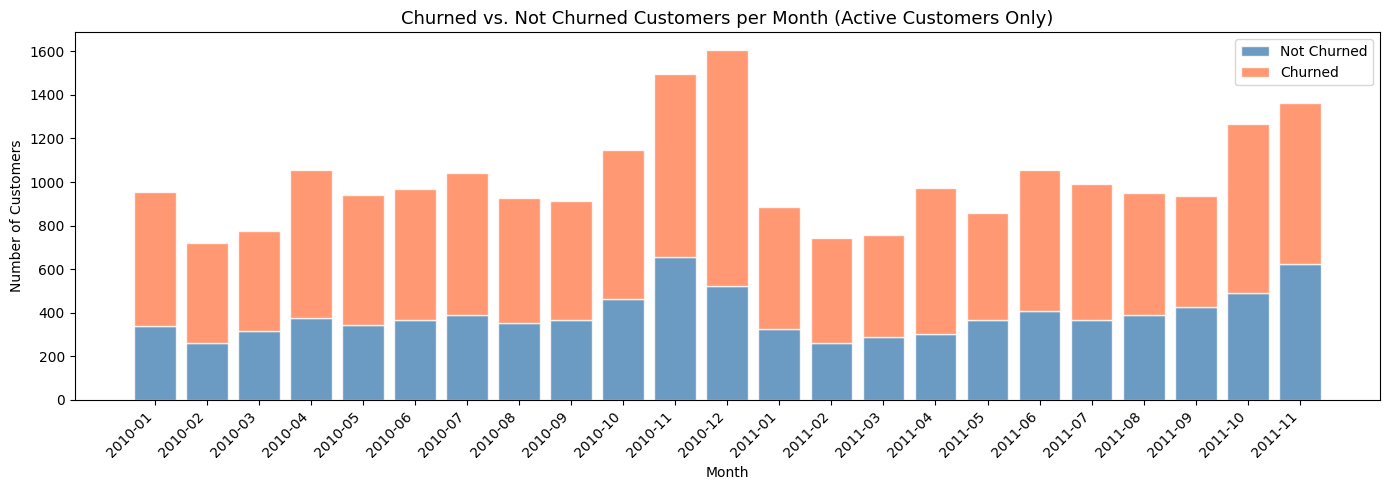

In [ ]:
churn_by_month = final_df_shifted.groupby(['year_month', 'churned']).size().unstack(fill_value=0)
churn_by_month.columns = ['Not Churned', 'Churned']
churn_by_month.index = churn_by_month.index.astype(str)

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(churn_by_month.index, churn_by_month['Not Churned'],
       color='steelblue', edgecolor='white', alpha=0.8, label='Not Churned')
ax.bar(churn_by_month.index, churn_by_month['Churned'],
       bottom=churn_by_month['Not Churned'],
       color='coral', edgecolor='white', alpha=0.8, label='Churned')

ax.set_xticks(range(len(churn_by_month)))
ax.set_xticklabels(churn_by_month.index, rotation=45, ha='right')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Customers')
ax.set_title('Churned vs. Not Churned Customers per Month (Active Customers Only)', fontsize=13)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
train_df = final_df_shifted[final_df_shifted.train_test_flag == 'train'].drop('train_test_flag',axis=1)
test_df = final_df_shifted[final_df_shifted.train_test_flag == 'test'].drop('train_test_flag',axis=1)

In [ ]:
train_df.head(5)

,Customer ID,year_month,churned,prev_total_revenue,prev_num_invoices,prev_avg_basket_size,prev_total_items,prev_unique_products
1,12346.0,2010-01,0,113.50,5.0,22.70,26.0,5.0
2,12346.0,2010-02,1,90.00,4.0,22.50,20.0,4.0
4,12346.0,2010-04,1,27.05,1.0,27.05,5.0,5.0
7,12346.0,2010-07,1,142.31,1.0,142.31,19.0,19.0
14,12346.0,2011-02,1,77183.60,1.0,77183.60,74215.0,1.0


In [ ]:
train_df.groupby('churned').count()

,Customer ID,year_month,prev_total_revenue,prev_num_invoices,prev_avg_basket_size,prev_total_items,prev_unique_products
churned,,,,,,,
0,8381,8381,8381,8381,8381,8381,8381
1,13573,13573,13573,13573,13573,13573,13573


In [ ]:
test_df.head(5)

,Customer ID,year_month,churned,prev_total_revenue,prev_num_invoices,prev_avg_basket_size,prev_total_items,prev_unique_products
47,12347.0,2011-11,1,1294.32,1.0,1294.320000,676.0,47.0
335,12359.0,2011-11,1,2876.85,1.0,2876.850000,657.0,100.0
359,12360.0,2011-11,1,1043.78,1.0,1043.780000,491.0,54.0
407,12362.0,2011-11,0,1641.91,3.0,547.303333,543.0,75.0
455,12364.0,2011-11,1,299.06,1.0,299.060000,268.0,22.0


In [ ]:
test_df.groupby('churned').count()

,Customer ID,year_month,prev_total_revenue,prev_num_invoices,prev_avg_basket_size,prev_total_items,prev_unique_products
churned,,,,,,,
0,622,622,622,622,622,622,622
1,742,742,742,742,742,742,742


# Quick Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, cohen_kappa_score, brier_score_loss, ConfusionMatrixDisplay, confusion_matrix)

feature_cols = ['prev_total_revenue', 'prev_num_invoices', 'prev_avg_basket_size', 'prev_total_items', 'prev_unique_products']

#train_df = final_df_shifted[final_df_shifted.train_test_flag == 'train'].drop('train_test_flag',axis=1)
#test_df = final_df_shifted[final_df_shifted.train_test_flag == 'test'].drop('train_test_flag',axis=1)

model = LogisticRegression()
model.fit(train_df[feature_cols], train_df['churned'])
y_pred = model.predict(test_df[feature_cols])
y_prob = model.predict_proba(test_df[feature_cols])[:, 1]

              precision    recall  f1-score   support

           0       0.81      0.20      0.32       622
           1       0.59      0.96      0.73       742

    accuracy                           0.61      1364
   macro avg       0.70      0.58      0.52      1364
weighted avg       0.69      0.61      0.54      1364



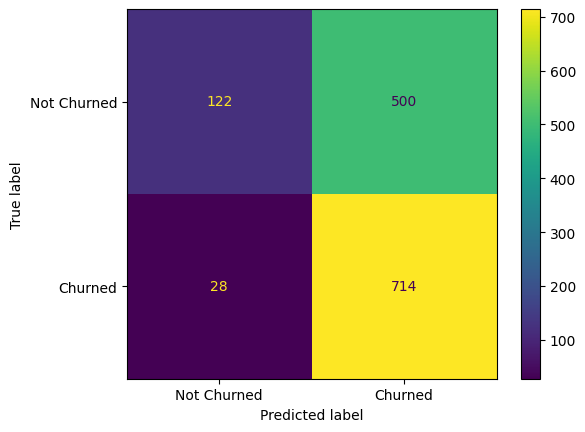

In [ ]:
print(classification_report(test_df['churned'], y_pred))
ConfusionMatrixDisplay(confusion_matrix(test_df['churned'], y_pred), display_labels=['Not Churned', 'Churned']).plot()
plt.show()

In [ ]:
print("=" * 55)
print(f"  Accuracy  : {accuracy_score(test_df['churned'], y_pred):.2%}")
print(f"             Of all customers, how many did we classify correctly?")
print("=" * 55)
print(f"  Precision : {precision_score(test_df['churned'], y_pred):.2%}")
print(f"             Of customers we flagged as churned, how many actually churned?")
print("=" * 55)
print(f"  Recall    : {recall_score(test_df['churned'], y_pred):.2%}")
print(f"             Of customers who actually churned, how many did we catch?")
print("-" * 55)
print(f"  F1 Score  : {f1_score(test_df['churned'], y_pred):.2%}")
print(f"             Balance between precision and recall.")
print("=" * 55)
print(f"  ROC-AUC   : {roc_auc_score(test_df['churned'], y_prob):.2%}")
print(f"             How well the model separates churners from non-churners.")
print("-" * 55)
print(f"  Kappa     : {cohen_kappa_score(test_df['churned'], y_pred):.2f}")
print(f"             How much better than random chance? (0=none, 1=perfect)")
print("=" * 55)
print(f"  Brier     : {brier_score_loss(test_df['churned'], y_prob):.4f}")
print(f"             Mean squared error of probability estimates. Closer to 0 is better.")
print("=" * 55)

  Accuracy  : 61.29%
             Of all customers, how many did we classify correctly?
  Precision : 58.81%
             Of customers we flagged as churned, how many actually churned?
  Recall    : 96.23%
             Of customers who actually churned, how many did we catch?
-------------------------------------------------------
  F1 Score  : 73.01%
             Balance between precision and recall.
  ROC-AUC   : 64.98%
             How well the model separates churners from non-churners.
-------------------------------------------------------
  Kappa     : 0.17
             How much better than random chance? (0=none, 1=perfect)
  Brier     : 0.2323
             Mean squared error of probability estimates. Closer to 0 is better.


## Is this a good model?

Last class we trained a Logistic Regression on 5 lag features
and got these results:

- Accuracy : 61%
- Precision: 59%
- Recall   : 96%
- Kappa    : 0.17

## We can't answer "is this a good model?" yet.

Before we look at any metric, we need to ask:
good at what, exactly?

A model is not good or bad in the abstract.
It is good or bad relative to a goal.

For churn prediction, we need to decide:
- What are we going to DO with the predictions?
- What is the cost of being wrong in each direction?

Only once we answer that can we pick the right metric —
and only then can we say whether the model is good.

## Class Imbalance

Before we try to fix the model, we need to understand **why** it's behaving this way.
Let's look at the class distribution in our training data.

Class distribution in training set:
  Not Churned (0):  8,381  (38.2%)
  Churned     (1): 13,573  (61.8%)

Class distribution in testing set:
  Not Churned (0):    622  (45.6%)
  Churned     (1):    742  (54.4%)


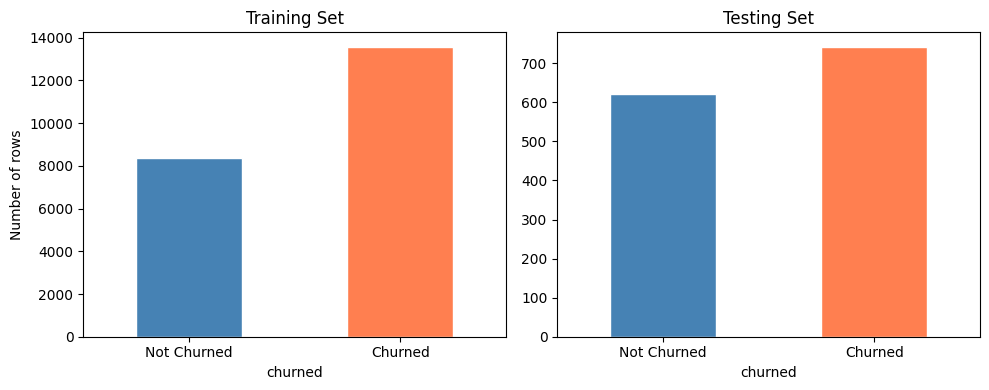

In [ ]:
# --- Training distribution ---
train_counts = train_df['churned'].value_counts()
train_pct = train_df['churned'].value_counts(normalize=True) * 100

# --- Testing distribution ---
test_counts = test_df['churned'].value_counts()
test_pct = test_df['churned'].value_counts(normalize=True) * 100

# --- Print results ---
print("Class distribution in training set:")
print(f"  Not Churned (0): {train_counts[0]:>6,}  ({train_pct[0]:.1f}%)")
print(f"  Churned     (1): {train_counts[1]:>6,}  ({train_pct[1]:.1f}%)")

print("\nClass distribution in testing set:")
print(f"  Not Churned (0): {test_counts[0]:>6,}  ({test_pct[0]:.1f}%)")
print(f"  Churned     (1): {test_counts[1]:>6,}  ({test_pct[1]:.1f}%)")
# Define consistent colors: [Not Churned, Churned]
colors = ['steelblue', 'coral']

# --- Training distribution ---
train_counts = train_df['churned'].value_counts().sort_index()
train_pct = train_df['churned'].value_counts(normalize=True).sort_index() * 100

# --- Testing distribution ---
test_counts = test_df['churned'].value_counts().sort_index()
test_pct = test_df['churned'].value_counts(normalize=True).sort_index() * 100

# --- Plot side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Training plot
train_counts.plot(
    kind='bar',
    ax=axes[0],
    color=colors,
    edgecolor='white'
)
axes[0].set_title('Training Set')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Not Churned', 'Churned'], rotation=0)
axes[0].set_ylabel('Number of rows')

# Testing plot
test_counts.plot(
    kind='bar',
    ax=axes[1],
    color=colors,
    edgecolor='white'
)
axes[1].set_title('Testing Set')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Not Churned', 'Churned'], rotation=0)

plt.tight_layout()
plt.show()

### What this tells us

The training set is skewed toward churned customers (about 62%), which is expected in a customer-month panel where many observations correspond to inactive periods.

The model picks up on this imbalance. Rather than predicting churn for everyone, it leans heavily toward predicting churn, because that is often the safer choice given the class distribution.

This leads to a model that:

- Captures most actual churners (very high recall),
- But flags many non-churners as churners (high false positives).

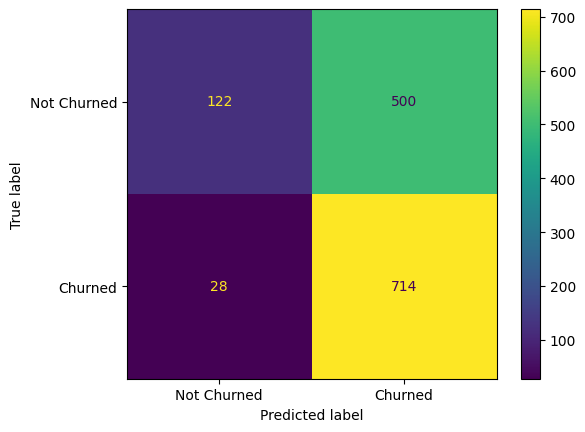

In [ ]:
ConfusionMatrixDisplay(confusion_matrix(test_df['churned'], y_pred), display_labels=['Not Churned', 'Churned']).plot()
plt.show()

The model flags 500 non-churned customers as churned, indicating a high number of false positives.

This suggests the model is **biased toward predicting churn**. It does learn signals associated with churn — as shown by its ability to correctly identify most churners — but it applies these signals too broadly, leading to many incorrect churn predictions.

This is why **accuracy is the wrong metric here**. A model that predicts “churned” for every customer would achieve a similar accuracy given the class imbalance. Accuracy therefore masks the model’s poor ability to distinguish between churners and non-churners.

### What can we do?

#### `class_weight='balanced'`

The simplest fix is to tell the model about the imbalance directly.
With `class_weight='balanced'`, sklearn automatically increases the penalty for
misclassifying the minority class during training — forcing the model to pay more
attention to not-churned customers.

This does not change the data. It changes how the optimizer weighs errors.

#### Undersampling

`class_weight='balanced'` adjusts how the model *thinks* about the imbalance,
but the training data itself is still skewed. Another approach is to fix the data
directly before training.

**Undersampling** removes rows from the majority class until the classes are balanced.
Instead of 80% churned / 20% not-churned, we train on 50/50 — a smaller but more
balanced dataset.

If the training dataset has 100 customers churning and 900 staying, on the testing dataset, the model will probably predict that 1 out of 10 customers churn.
However, if we removed 800 staying customers from the dataset, our training dataset will have 100 customers churning and 100 customers staying.
The model will learn that pattern, and apply it to the testing dataset.

The tradeoff: we are throwing away real data. The model trains on less information,
which can hurt performance in other ways. But for heavily imbalanced datasets like
this one, the gain from balance often outweighs the loss from smaller size.

#### Adjusting the Decision Threshold

Both previous approaches changed something about the training process — either the
loss function weights or the data itself. This approach changes neither. Instead, it
changes **how we interpret the model's output after training**.

By default, sklearn predicts "churned" when the predicted probability is ≥ 0.50.
But that cutoff is arbitrary. The model produces a probability — the threshold is
our choice.

- **Lower the threshold** → more customers get flagged as churned → higher recall,
  more false positives
- **Raise the threshold** → fewer customers get flagged → fewer false positives,
  but we miss more real churners

This is the same precision-recall tradeoff, just controlled at the prediction stage
rather than the training stage.

## Our metrics:

### Accuracy — 61%

formula: correct predictions / all predictions

VERDICT: Misleading here. Do not use alone on imbalanced data.

A model that shouts "churned!" at every single customer
scores 74% accuracy — higher than ours.

When one class dominates, accuracy rewards laziness.
Our model is actually WORSE than always predicting churn.

Not Churned : 8,381
Churned     : 13,573
Churn rate  : 61.8%

A model predicting 'churned' for everyone gets 61.8% accuracy.
Our model got 61%. We are WORSE than the dumb model.


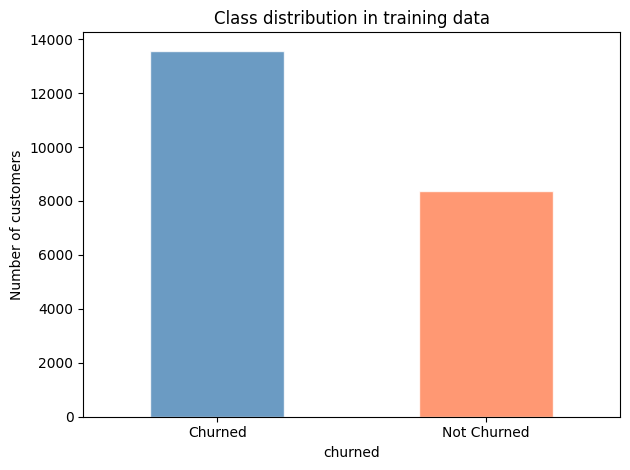

In [ ]:
# How imbalanced is the training data?
counts = train_df['churned'].value_counts()
rate = counts[1] / len(train_df)

print(f"Not Churned : {counts[0]:,}")
print(f"Churned     : {counts[1]:,}")
print(f"Churn rate  : {rate:.1%}")
print()
print(f"A model predicting 'churned' for everyone gets {rate:.1%} accuracy.")
print(f"Our model got 61%. We are WORSE than the dumb model.")

counts.plot(kind='bar', color=['steelblue', 'coral'],
            edgecolor='white', alpha=0.8)
plt.xticks([0, 1], ['Churned', 'Not Churned'], rotation=0)
plt.title('Class distribution in training data')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.show()

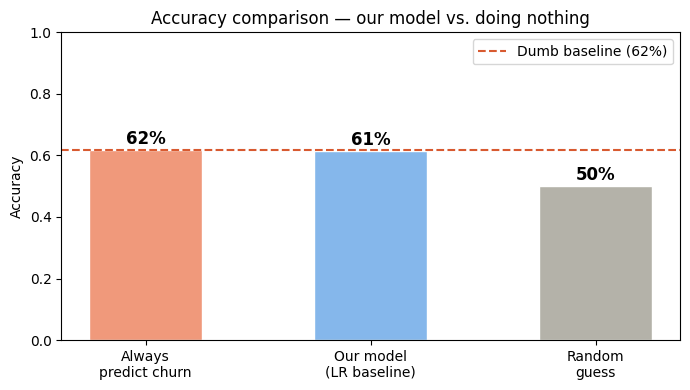

In [ ]:
# Bar chart: our model vs naive vs random
models = ['Always\npredict churn', 'Our model\n(LR baseline)', 'Random\nguess']
accuracies = [rate, accuracy_score(test_df['churned'], y_pred), 0.5]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(models, accuracies, color=['#F0997B', '#85B7EB', '#B4B2A9'],
              edgecolor='white', width=0.5)
ax.axhline(rate, color='#D85A30', linewidth=1.5, linestyle='--',
           label=f'Dumb baseline ({rate:.0%})')
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy comparison — our model vs. doing nothing')
for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.0%}', ha='center', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Recall — 96%

formula: true positives / (true positives + false negatives)
= of customers who actually churned, how many did we catch?

VERDICT: Good — but dangerously easy to game.

A model that flags EVERYONE as churned also gets 100% recall.
High recall alone tells us nothing unless we control false alarms.

Our model caught 714 out of 742 real churners. That sounds great.
But it also flagged 500 customers who were NOT going to churn.

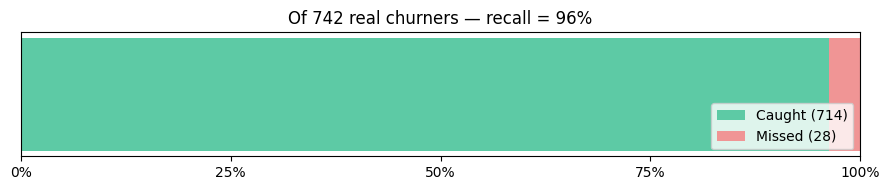

In [ ]:
total_churners = 742
caught = 714
missed = total_churners - caught

fig, ax = plt.subplots(figsize=(9, 2))
ax.barh(0, caught/total_churners, color='#5DCAA5', height=0.4,
        label=f'Caught ({caught})')
ax.barh(0, missed/total_churners, left=caught/total_churners,
        color='#F09595', height=0.4, label=f'Missed ({missed})')
ax.set_xlim(0, 1)
ax.set_yticks([])
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticklabels(['0%', '25%', '50%', '75%', '100%'])
ax.set_title(f'Of {total_churners} real churners — recall = {caught/total_churners:.0%}')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
# What does a naive "predict everyone churns" model score?
y_naive = [1] * len(test_df)

print("Naive model — predict churned for everyone:")
print(f"  Accuracy : {accuracy_score(test_df['churned'], y_naive):.1%}")
print(f"  Recall   : {recall_score(test_df['churned'], y_naive):.1%}")
print(f"  Precision: {precision_score(test_df['churned'], y_naive):.1%}")
print(f"  F1 Score : {f1_score(test_df['churned'], y_naive):.1%}")
print(f"  Kappa    : {cohen_kappa_score(test_df['churned'], y_naive):.2f}")

Naive model — predict churned for everyone:
  Accuracy : 54.4%
  Recall   : 100.0%
  Precision: 54.4%
  F1 Score : 70.5%
  Kappa    : 0.00


### Precision — 59%

formula: true positives / (true positives + false positives)
= of customers we flagged as churned, how many actually churned?

500 customers were flagged as churners who were NOT going to leave.
For every real churner we correctly identify, we also send
roughly 0.7 unnecessary alerts.

Whether that is acceptable depends entirely on your intervention cost.

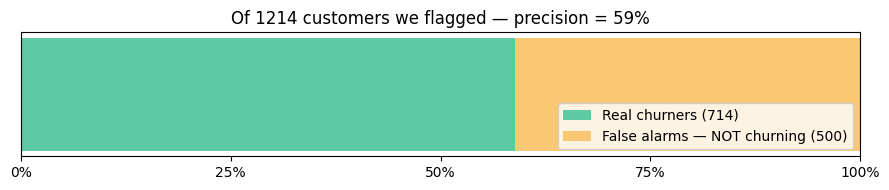

In [ ]:
tp_val = 714
fp_val = 500
total_flagged = tp_val + fp_val

fig, ax = plt.subplots(figsize=(9, 2))
ax.barh(0, tp_val/total_flagged, color='#5DCAA5', height=0.4,
        label=f'Real churners ({tp_val})')
ax.barh(0, fp_val/total_flagged, left=tp_val/total_flagged,
        color='#FAC775', height=0.4,
        label=f'False alarms — NOT churning ({fp_val})')
ax.set_xlim(0, 1)
ax.set_yticks([])
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticklabels(['0%', '25%', '50%', '75%', '100%'])
ax.set_title(f'Of {total_flagged} customers we flagged — precision = {tp_val/total_flagged:.0%}')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### What is the False Positive Rate?

A **false positive** is a customer the model predicted would churn — but who was
never going to leave.

The **False Positive Rate (FPR)** measures how many of those non-churning customers
we incorrectly flagged:

$$FPR = \frac{False\ Positives}{False\ Positives + True\ Negatives} = \frac{FP}{FP + TN}$$

In plain terms: *of all the customers who were NOT going to churn, what fraction did
we bother anyway?*

Going back to our confusion matrix:

|  | Predicted: Not Churned | Predicted: Churned |
|---|---|---|
| **Actually: Not Churned** | 122 ✅ TN | 500 ❌ FP |
| **Actually: Churned** | 28 ❌ FN | 714 ✅ TP |

$$FPR = \frac{500}{500 + 122} = 0.805 = 80.5\%$$

Our model incorrectly flagged **80.5% of loyal customers as churners**.

If your marketing team acts on these predictions, 4 out of every 5 customers they
contact were never at risk. That is an expensive mistake — in time, budget, and
potentially in customer experience (nobody likes being told they seem unhappy when
they aren't).

Normally, we would like to keep that value below 20%


### FPR vs. Precision — two ways to measure the same problem

FPR and Precision are both telling you something about false positives, just from
different angles:

| Metric | Question it answers |
|---|---|
| **FPR** | Of everyone who was NOT going to churn, how many did we flag? |
| **Precision** | Of everyone we flagged as churning, how many actually were? |

FPR looks at the false positives **relative to the true negatives** — it is a rate
within the non-churned population.

Precision looks at the false positives **relative to all your predictions** — it tells
you how trustworthy your churn flag is.

Both matter. Which one you optimize for depends on the business context.

### F1 Score — 73%

formula: 2 × (precision × recall) / (precision + recall)
= harmonic mean of precision and recall

VERDICT: Good practical summary. Hard to game.

A model that predicts everyone as churned gets:
- Recall  = 100%
- Precision ≈ 74% (the base churn rate)
- F1 ≈ 85%

So F1 is still inflated on imbalanced data — but much less so than
accuracy or recall alone. It punishes both low precision and low recall.

Good default metric when you have no strong reason to weight
recall over precision or vice versa.

### ROC-AUC — 65%

formula: area under the recall vs. false positive rate curve

VERDICT: Our most honest metric. And 65% is worrying.

- 0.50 = random coin flip (no skill at all)
- 0.65 = slight skill (our model)
- 0.80 = good
- 0.90+ = excellent

ROC-AUC measures how well the model RANKS churners above
non-churners across ALL possible decision thresholds.
It is not affected by class imbalance.

65% means we are only slightly better than guessing.
Our 5 lag features are not enough.
This is exactly why we need better features.

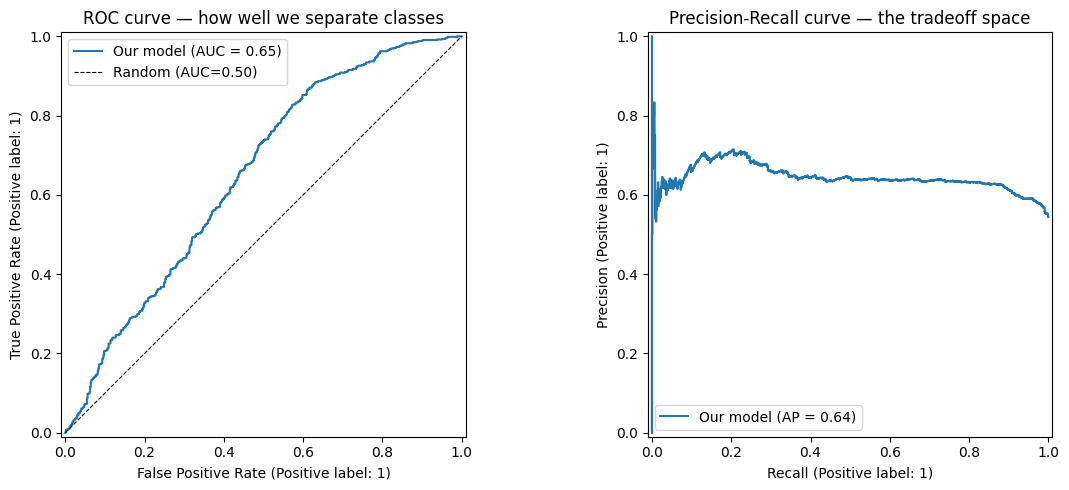

In [ ]:
# Visualize the precision-recall tradeoff
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    test_df['churned'], y_prob, ax=axes[0], name='Our model'
)
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random (AUC=0.50)')
axes[0].set_title('ROC curve — how well we separate classes')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(
    test_df['churned'], y_prob, ax=axes[1], name='Our model'
)
axes[1].set_title('Precision-Recall curve — the tradeoff space')

plt.tight_layout()
plt.show()

### Kappa (Cohen's κ) — 0.17

formula: (observed accuracy - expected accuracy) / (1 - expected accuracy)
= how much better than random chance, accounting for imbalance

VERDICT: Almost random. This is the reality check.

- 0.00 = no better than random
- 0.17 = very weak (our model)
- 0.40 = moderate
- 0.60 = good
- 1.00 = perfect

Even though recall looks impressive at 96%, Kappa exposes
that the model barely knows what it is doing.

Watch this number as you add features.
If Kappa does not move, your features are not helping.

## Summary — which metrics to use

| Metric | Our score | Use it? | Why |
|---|---|---|---|
| Accuracy | 61% | Never alone | Beaten by dumb baseline |
| Recall | 96% | Context only | Easy to game — means nothing alone |
| Precision | 59% | Context only | Depends on intervention cost |
| F1 Score | 73% | Yes | Balanced, hard to game |
| ROC-AUC | 65% | Yes — primary | Honest, imbalance-robust |
| Kappa | 0.17 | Yes — primary | Reality check, beats-random test |


## Precision, Recall and the Threshold

When we call `model.predict()`, sklearn applies a hidden rule:
- > if probability >= 0.50 → predict "churned"
- > if probability < 0.50  → predict "not churned"

That 0.50 is called the **decision threshold** — and it is completely arbitrary.
We chose it by doing nothing.

The model actually outputs a *probability* for every customer.
A customer with probability 0.51 and one with probability 0.95
both get predicted as "churned" — but they are very different cases.

**Changing the threshold changes every metric.**
Let's see exactly how.

### First: let's look at the raw probabilities

We will plot every customer as a dot on a 0–1 probability axis.
- Orange dots = customers who actually churned
- Blue dots   = customers who did NOT churn

A perfect model would separate them completely.
Our model overlaps them. The threshold decides where we draw the line.

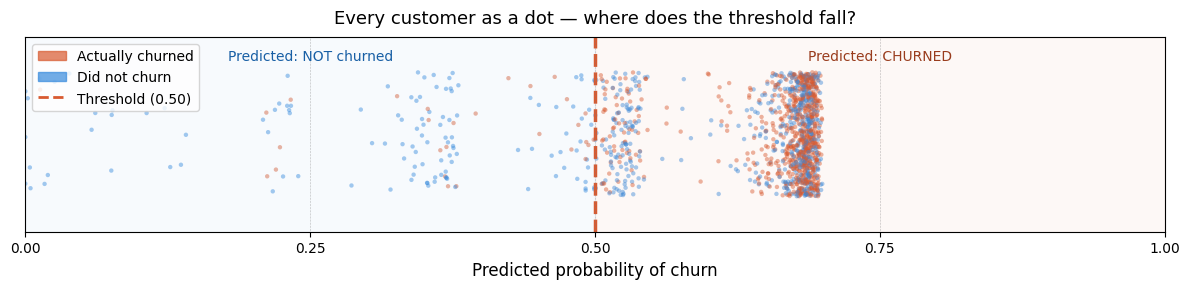

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Use your actual model probabilities
# y_prob     = model.predict_proba(test_df[feature_cols])[:, 1]
# y_true_arr = test_df['churned'].values

y_true_arr = test_df['churned'].values
y_prob_arr = model.predict_proba(test_df[feature_cols])[:, 1]

THRESHOLD = 0.50   # <-- change this and re-run

np.random.seed(0)
jitter = np.random.uniform(-0.35, 0.35, len(y_true_arr))
colors = np.where(y_true_arr == 1, '#D85A30', '#378ADD')

fig, ax = plt.subplots(figsize=(12, 3))

ax.scatter(y_prob_arr, jitter, c=colors, s=10, alpha=0.45, linewidths=0)

# Threshold line
ax.axvline(THRESHOLD, color='#D85A30', linewidth=2.5, linestyle='--',
           label=f'Threshold = {THRESHOLD:.2f}')

# Shading: left = predicted not churned, right = predicted churned
ax.axvspan(0, THRESHOLD, alpha=0.04, color='#378ADD')
ax.axvspan(THRESHOLD, 1, alpha=0.04, color='#D85A30')

ax.text(THRESHOLD / 2, 0.48, 'Predicted: NOT churned',
        ha='center', va='top', fontsize=10, color='#185FA5')
ax.text((1 + THRESHOLD) / 2, 0.48, 'Predicted: CHURNED',
        ha='center', va='top', fontsize=10, color='#993C1D')

ax.set_xlim(0, 1)
ax.set_ylim(-0.55, 0.55)
ax.set_xlabel('Predicted probability of churn', fontsize=12)
ax.set_yticks([])
ax.set_title('Every customer as a dot — where does the threshold fall?',
             fontsize=13, pad=10)

legend_elements = [
    mpatches.Patch(color='#D85A30', alpha=0.7, label='Actually churned'),
    mpatches.Patch(color='#378ADD', alpha=0.7, label='Did not churn'),
    plt.Line2D([0], [0], color='#D85A30', linewidth=2,
               linestyle='--', label=f'Threshold ({THRESHOLD:.2f})')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

for v in [0.25, 0.50, 0.75]:
    ax.axvline(v, color='gray', linewidth=0.4, linestyle=':')
ax.set_xticks([0, 0.25, 0.50, 0.75, 1.0])
ax.set_xticklabels(['0.00', '0.25', '0.50', '0.75', '1.00'])

plt.tight_layout()
plt.show()

### What happens when we move the threshold?

- Move it LEFT  → we flag more customers as churned
  - Recall goes UP   (we catch more real churners)
  - Precision goes DOWN (we also flag more non-churners)

- Move it RIGHT → we only flag high-confidence churners
  - Precision goes UP  (fewer false alarms)
  - Recall goes DOWN   (we miss more real churners)

You cannot improve both at the same time.
That is the tradeoff.

Let's measure it at every possible threshold.

/tmp/ipykernel_1631/1173529073.py:12: RuntimeWarning: invalid value encountered in divide
  2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1]),


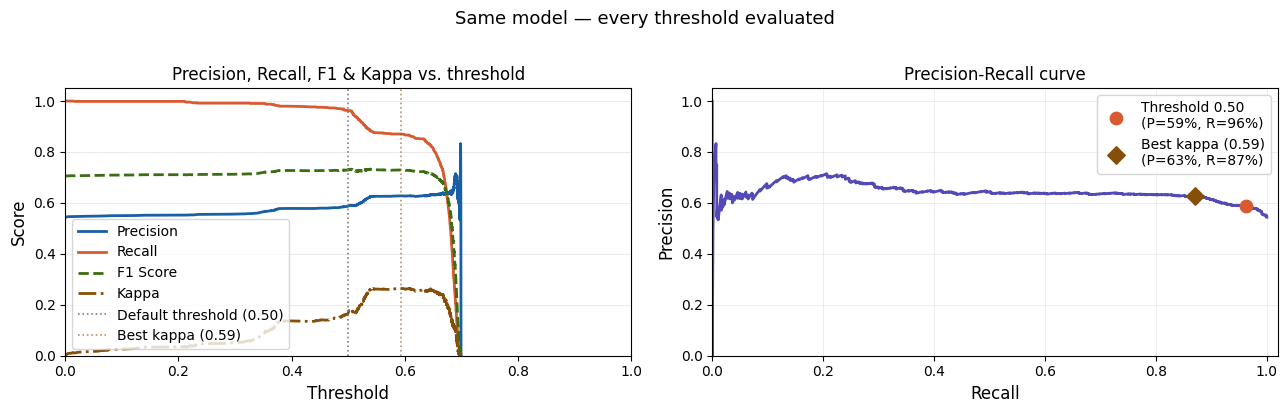

At default threshold 0.50 — Kappa: 0.17
At best kappa threshold 0.59 — Kappa: 0.26


In [ ]:
from sklearn.metrics import (
    precision_recall_curve, roc_curve, auc,
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    cohen_kappa_score
)

# Precision, recall, F1 come free from precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_true_arr, y_prob_arr)
f1_scores = np.where(
    (precisions[:-1] + recalls[:-1]) > 0,
    2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1]),
    0
)

# Kappa needs a loop — it requires the full confusion matrix at each threshold
kappas = np.array([
    cohen_kappa_score(y_true_arr, (y_prob_arr >= t).astype(int))
    for t in thresholds
])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Left plot: metrics vs threshold ---
axes[0].plot(thresholds, precisions[:-1], color='#185FA5',
             linewidth=2, label='Precision')
axes[0].plot(thresholds, recalls[:-1],    color='#D85A30',
             linewidth=2, label='Recall')
axes[0].plot(thresholds, f1_scores,       color='#3B6D11',
             linewidth=2, linestyle='--', label='F1 Score')
axes[0].plot(thresholds, kappas,          color='#854F0B',
             linewidth=2, linestyle='-.', label='Kappa')

axes[0].axvline(0.50, color='gray', linewidth=1.2, linestyle=':',
                label='Default threshold (0.50)')

# Mark the threshold where kappa peaks
best_kappa_idx = np.argmax(kappas)
best_kappa_thresh = thresholds[best_kappa_idx]
axes[0].axvline(best_kappa_thresh, color='#854F0B', linewidth=1.2,
                linestyle=':', alpha=0.6,
                label=f'Best kappa ({best_kappa_thresh:.2f})')

axes[0].set_xlabel('Threshold', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Precision, Recall, F1 & Kappa vs. threshold', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis='y', linewidth=0.4, alpha=0.5)

# --- Right plot: Precision-Recall curve ---
axes[1].plot(recalls, precisions, color='#534AB7', linewidth=2)
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall curve', fontsize=12)
axes[1].set_xlim(0, 1.02)
axes[1].set_ylim(0, 1.05)
axes[1].grid(linewidth=0.4, alpha=0.4)

# Mark default threshold operating point
y_pred_default = (y_prob_arr >= 0.50).astype(int)
p_default = precision_score(y_true_arr, y_pred_default)
r_default = recall_score(y_true_arr, y_pred_default)
axes[1].scatter([r_default], [p_default], color='#D85A30', s=80, zorder=5,
                label=f'Threshold 0.50\n(P={p_default:.0%}, R={r_default:.0%})')

# Mark best kappa operating point on the PR curve
y_pred_kappa = (y_prob_arr >= best_kappa_thresh).astype(int)
p_kappa = precision_score(y_true_arr, y_pred_kappa)
r_kappa = recall_score(y_true_arr, y_pred_kappa)
axes[1].scatter([r_kappa], [p_kappa], color='#854F0B', s=80, zorder=5, marker='D',
                label=f'Best kappa ({best_kappa_thresh:.2f})\n(P={p_kappa:.0%}, R={r_kappa:.0%})')

axes[1].legend(fontsize=10)

plt.suptitle('Same model — every threshold evaluated', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"At default threshold 0.50 — Kappa: {cohen_kappa_score(y_true_arr, y_pred_default):.2f}")
print(f"At best kappa threshold {best_kappa_thresh:.2f} — Kappa: {kappas[best_kappa_idx]:.2f}")

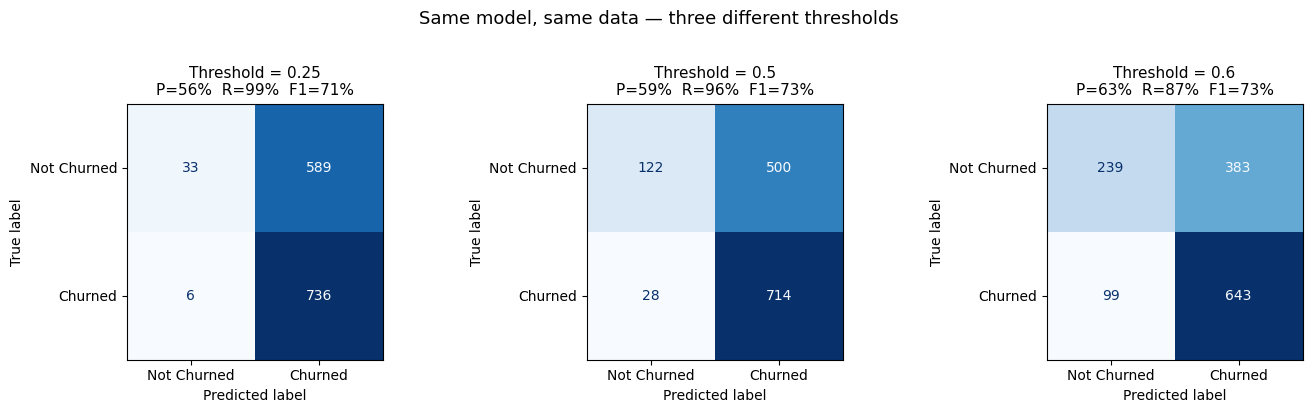

In [ ]:
thresholds_to_compare = [0.25, 0.50, 0.60]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, t in zip(axes, thresholds_to_compare):
    y_pred_t = (y_prob_arr >= t).astype(int)
    cm = confusion_matrix(y_true_arr, y_pred_t)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Churned', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')

    prec_t = precision_score(y_true_arr, y_pred_t)
    rec_t  = recall_score(y_true_arr, y_pred_t)
    f1_t   = f1_score(y_true_arr, y_pred_t)

    ax.set_title(
        f'Threshold = {t}\n'
        f'P={prec_t:.0%}  R={rec_t:.0%}  F1={f1_t:.0%}',
        fontsize=11
    )

plt.suptitle('Same model, same data — three different thresholds',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
def evaluate_threshold(threshold, y_true, y_prob, verbose=True):
    """Compute all metrics at a given threshold."""
    y_pred = (y_prob >= threshold).astype(int)

    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())

    prec  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec   = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1    = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    kappa = cohen_kappa_score(y_true, y_pred)

    # ✅ NEW: False Positive Rate
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    if verbose:
        print(f"\nThreshold = {threshold:.2f}")
        print(f"  Flagged as churned : {tp + fp:,}  ({(tp+fp)/len(y_true):.0%} of all customers)")
        print(f"  Precision          : {prec:.1%}  — of flagged, truly churned")
        print(f"  Recall             : {rec:.1%}  — of churners, caught")
        print(f"  F1 Score           : {f1:.1%}")
        print(f"  Kappa              : {kappa:.2f}")
        print(f"  False Positive Rate: {fpr:.1%}")
        print()
        print(f"  Confusion matrix:")
        print(f"    True Negative  (correctly not flagged) : {tn:,}")
        print(f"    False Positive (flagged, not churner)  : {fp:,}  ← unnecessary contacts")
        print(f"    False Negative (missed churner)        : {fn:,}  ← lost customers")
        print(f"    True Positive  (correctly caught)      : {tp:,}")
        print()
        print(f"  In plain English    : of every 100 customers who were NOT")
        print(f"                        going to leave, we wrongly contact")
        print(f"                        {fpr*100:.0f} of them.")

    return dict(threshold=threshold, precision=prec, recall=rec,
                f1=f1, kappa=kappa, fpr=fpr,
                tp=tp, fp=fp, fn=fn, tn=tn)

In [ ]:
# Goal: keep False Positive Rate <= 20%
# Among thresholds that satisfy that, MAXIMISE RECALL
# (catch as many churners as possible without too many false alarms)

results = []
for t in np.arange(0.10, 0.91, 0.01):
    r = evaluate_threshold(round(t, 2),
                           test_df['churned'].values,
                           y_prob,
                           verbose=False)
    fpr = r['fp'] / (r['fp'] + r['tn']) if (r['fp'] + r['tn']) > 0 else 0
    r['fpr'] = fpr
    results.append(r)

print("=" * 55)
print("Goal: highest Recall with FPR <= 20%")
print("Catch as many churners as possible,")
print("while contacting no more than 20 in 100 non-churners.")
print("=" * 55)

candidates = [r for r in results if r['fpr'] <= 0.20]

if candidates:
    best = max(candidates, key=lambda r: r['recall'])  # <- changed from f1
    tuned_thresh = best['threshold']
    evaluate_threshold(tuned_thresh,
                       test_df['churned'].values,
                       y_prob,
                       verbose=True)
    print(f"  False positive rate : {best['fpr']:.1%}  "
          f"({best['fp']:,} non-churners wrongly flagged)")
    print(f"  In plain English    : of every 100 customers who were NOT")
    print(f"                        going to leave, we wrongly contact")
    print(f"                        {best['fpr']*100:.0f} of them.")
else:
    print("No threshold satisfies FPR <= 20%.")
    print("The features are not strong enough to separate the classes.")
    tuned_thresh = 0.68


y_pred_tuned = (y_prob >= tuned_thresh).astype(int)

Goal: highest Recall with FPR <= 20%
Catch as many churners as possible,
while contacting no more than 20 in 100 non-churners.

Threshold = 0.69
  Flagged as churned : 214  (16% of all customers)
  Precision          : 71.5%  — of flagged, truly churned
  Recall             : 20.6%  — of churners, caught
  F1 Score           : 32.0%
  Kappa              : 0.10
  False Positive Rate: 9.8%

  Confusion matrix:
    True Negative  (correctly not flagged) : 561
    False Positive (flagged, not churner)  : 61  ← unnecessary contacts
    False Negative (missed churner)        : 589  ← lost customers
    True Positive  (correctly caught)      : 153

  In plain English    : of every 100 customers who were NOT
                        going to leave, we wrongly contact
                        10 of them.
  False positive rate : 9.8%  (61 non-churners wrongly flagged)
  In plain English    : of every 100 customers who were NOT
                        going to leave, we wrongly contact
            

### What we just learned

1. The model outputs **probabilities** — the 0.50 threshold is just a default.

2. **Lowering the threshold** → more customers flagged
   → Recall up, Precision down, more false alarms

3. **Raising the threshold** → fewer customers flagged
   → Precision up, Recall down, more missed churners

4. The **Precision-Recall curve** shows every possible tradeoff.
   The area under it (AP score) summarises the model's overall quality.

5. The **right threshold** depends on the cost of your intervention —
   that is a business decision, not a data science one.

6. For this dataset (low-cost email intervention):
   → Optimise for F1, or set recall >= 90% and maximise precision.
   → Never just use 0.50 because it is the default.


## Our Approaches for Imbalance

1) Baseline (no correction)
2) class_weight='balanced'
3) Undersampling
4) Adjusting threshold

In [ ]:
##ModuleNotFoundError: No module named 'imblearn' --> Open cmd, and run "python -m pip install imblearn"

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             cohen_kappa_score, roc_auc_score, f1_score,
                             precision_score, recall_score)
from imblearn.under_sampling import RandomUnderSampler

# ── Approach 1: baseline (no correction) ──────────────────────────
model_base = LogisticRegression(max_iter=1000)
model_base.fit(train_df[feature_cols], train_df['churned'])
y_pred_base = model_base.predict(test_df[feature_cols])
y_prob_base = model_base.predict_proba(test_df[feature_cols])[:, 1]

# ── Approach 2: class_weight='balanced' ───────────────────────────
# Tells the model to penalize minority-class mistakes more heavily
# during training. Does NOT change the data — changes the loss function.
model_bal = LogisticRegression(class_weight='balanced', max_iter=1000)
model_bal.fit(train_df[feature_cols], train_df['churned'])
y_pred_bal = model_bal.predict(test_df[feature_cols])
y_prob_bal = model_bal.predict_proba(test_df[feature_cols])[:, 1]

# ── Approach 3: undersampling ──────────────────────────────────────
# Randomly remove majority-class rows until classes are equal.
# Simple but throws away real data.
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(
    train_df[feature_cols], train_df['churned']
)

# Fit model on undersampled training data
model_under = LogisticRegression(max_iter=1000)
model_under.fit(X_under, y_under)

# Predict on the original test set
y_pred_under = model_under.predict(test_df[feature_cols])
y_prob_under = model_under.predict_proba(test_df[feature_cols])[:, 1]

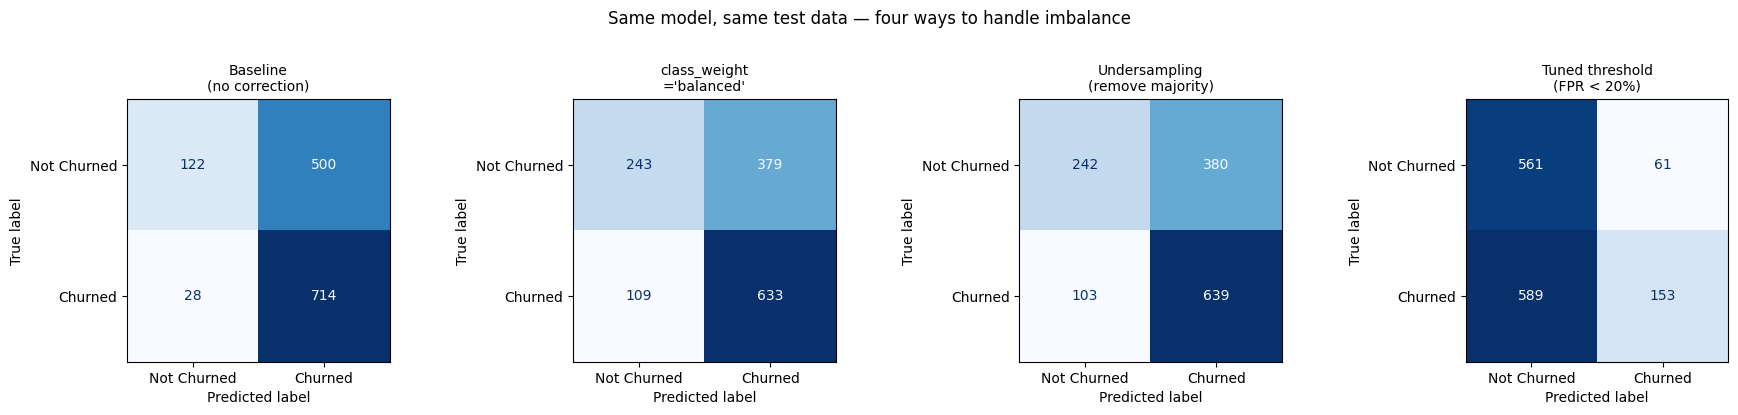

In [ ]:
# ── Plot 1: confusion matrices side by side ────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

configs = [
    (y_pred_base,  'Baseline\n(no correction)'),
    (y_pred_bal,   "class_weight\n='balanced'"),
    (y_pred_under, 'Undersampling\n(remove majority)'),
    (y_pred_tuned, 'Tuned threshold\n(FPR < 20%)'),
]

for ax, (y_pred_i, title) in zip(axes, configs):
    ConfusionMatrixDisplay(
        confusion_matrix(test_df['churned'], y_pred_i),
        display_labels=['Not Churned', 'Churned']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=10)

plt.suptitle('Same model, same test data — four ways to handle imbalance',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

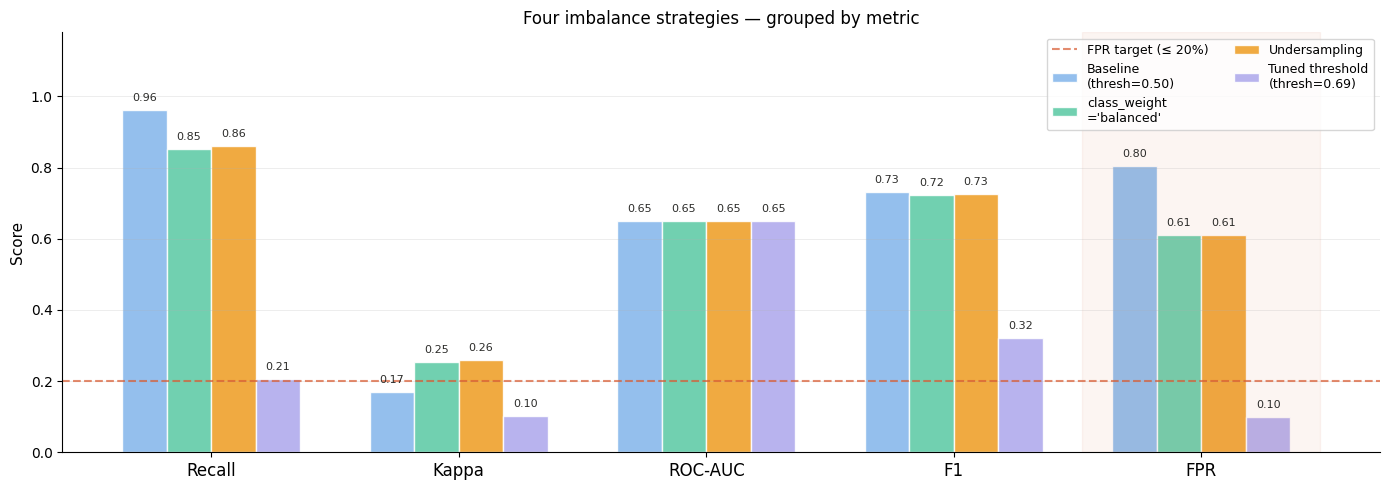

In [ ]:
import numpy as np

labels  = ['Baseline\n(thresh=0.50)',
           "class_weight\n='balanced'",
           'Undersampling',
           f'Tuned threshold\n(thresh={tuned_thresh:.2f})']
colors  = ['#85B7EB', '#5DCAA5', '#EF9F27', '#AFA9EC']

y_preds = [y_pred_base, y_pred_bal, y_pred_under, y_pred_tuned]
y_probs = [y_prob_base, y_prob_bal, y_prob_under, y_prob_base]  # same probs, different cut

recalls  = [recall_score(test_df['churned'], y)          for y in y_preds]
kappas   = [cohen_kappa_score(test_df['churned'], y)      for y in y_preds]
roc_aucs = [roc_auc_score(test_df['churned'], y)          for y in y_probs]
f1s      = [f1_score(test_df['churned'], y)               for y in y_preds]
fprs     = [(((y==1) & (test_df['churned'].values==0)).sum() /
             (test_df['churned'].values==0).sum())         for y in y_preds]

metric_labels = ['Recall', 'Kappa', 'ROC-AUC', 'F1', 'FPR']
metric_values = [recalls, kappas, roc_aucs, f1s, fprs]

x       = np.arange(len(metric_labels))
width   = 0.18
offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * width

fig, ax = plt.subplots(figsize=(14, 5))

for i, (label, color, offset) in enumerate(zip(labels, colors, offsets)):
    values = [metric_values[m][i] for m in range(len(metric_labels))]
    bars   = ax.bar(x + offset, values, width,
                    label=label, color=color,
                    edgecolor='white', alpha=0.88)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + 0.02, f'{val:.2f}',
                ha='center', va='bottom',
                fontsize=8, color='#2C2C2A')

# FPR target line
ax.axhline(0.20, color='#D85A30', linewidth=1.5, linestyle='--',
           alpha=0.7, label='FPR target (≤ 20%)')

# Shade FPR group
ax.axvspan(x[-1] - 0.48, x[-1] + 0.48,
           alpha=0.06, color='#D85A30')

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=12)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Four imbalance strategies — grouped by metric',
             fontsize=12)
ax.legend(fontsize=9, loc='upper right', ncol=2)
ax.grid(axis='y', linewidth=0.4, alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Conclusion — What did we learn?

We tried four different strategies to deal with class imbalance, and none of them
produced a model we would feel confident deploying.

Look at the chart:

- **Recall** is high on the baseline — but only because the model is predicting
  churn for almost everyone. That is not skill, that is bias toward the majority class.
- **Kappa** is low across all four strategies. Kappa measures how much better than
  random chance we are. A Kappa below 0.20 is generally considered poor agreement.
  We are barely beating a coin flip.
- **ROC-AUC** hovers around 0.60–0.65 across all strategies. A random classifier
  scores 0.50. We are not much better.
- **FPR** only gets under the 20% target with the tuned threshold — but at that
  point recall collapses. We are catching very few real churners.

No strategy wins on all metrics simultaneously. That is not a surprise — but the
*level* of performance across the board tells us something important:

> **The problem is not the imbalance strategy. The problem is the data.**

Balancing techniques help the model pay attention to the right class. They cannot
invent signal that isn't there. If the features we are feeding the model do not
actually explain who churns and who doesn't, no amount of resampling or threshold
tuning will fix that.

---

### What should we do next?

**1. Build better features.**
The `_prev` lag features are a reasonable starting point, but crude. A customer's
revenue last month tells the model very little about whether they are about to leave.
More predictive signals might include:
- Trend over the last 3–6 months (is revenue declining?)
- How long since their very first purchase (tenure)
- Whether they have ever gone quiet before and come back
- Seasonality — are they a holiday-only buyer?

**2. Address missing data more carefully.**
We filled all missing `_prev` values with zero. For a customer's first observed
month that is defensible. But for customers with gaps in their history, zero may
be misleading — it looks like no activity when the real issue is simply missing data.
We will revisit this in the imputation lesson.

**3. Apply more rigorous data preprocessing.**
Several preprocessing steps were skipped or handled superficially:

- **Feature scaling** — logistic regression couldn't converge because our features
  operate on wildly different scales. Revenue is in the thousands; num_invoices is
  in single digits. We will fix this properly in the next lesson.
- **Outlier treatment** — extreme values in revenue and quantity are still in the
  data. We flagged them in EDA but passed them through to the model untouched. A
  single high-revenue wholesaler can distort the model significantly.
- **Collinearity** — `prev_total_revenue`, `prev_total_items`, and
  `prev_avg_basket_size` are almost certainly correlated — revenue is just
  quantity × price. Redundant features add noise without adding information.
  A correlation heatmap will show us which ones to remove.
- **Feature selection** — once we have a richer feature set, we need a principled
  way to decide which features are actually contributing. We will cover feature
  importance and permutation importance in a later lesson.
- **Imputation** — the zero-fill decision deserves more scrutiny. We will revisit
  it when we cover missing data strategies formally.

**4. Consider how the model choice affects preprocessing decisions.**
Logistic Regression assumes a linear relationship between features and the log-odds
of churning — and it requires scaling. Tree-based models (Random Forest, Gradient
Boosting) make no such assumption, are scale-invariant, and are generally more
robust to outliers and skewed distributions. The right preprocessing pipeline
depends partly on which model you intend to use.

## Scott's Submission Starts Here

### Business Scenario
* Ever customer predicted as "churn" will be contacted
* Each contact costs $10

* If a customer actually churns, the company loses approximately $200 in future revenue I'll assume that is the NPV of the revenue

### Calculation
We want to ensure that the amount saved is greater than the contact cost for a given contact. So we want to keep \$200 saved * chance of churning threshold > \$10. This would indicate an optimal threshhold of 10/200 or 0.05. It occurs to me that this assumes 100% success of the coupon. So the real formula is \$200 * chance of churning * chance of coupon success > \$10.

The coupon succcess is a business value that we don't know. Presumably the business would have some knowledge of this - perhaps gathered from A/B testing. Here I'll guess 12.5% to make the calculation interesting. In other words we expect 12.5% success for each contact. So our new formula is

```
$200 * threshold * 0.125 > $10
```
This indicates an optimal threshold of 0.4.

In [ ]:
# JSP 20260428 - I asked an AI to give me a python function to calculate optimal
#                thresholds and savings for multiple coupon success rates
#.               then I customized for our implementation.
# Cost-aware evaluation across thresholds and retention rates
COST_CONTACT = 10
LOSS_CHURN   = 200

def expected_cost(y_true, y_prob, threshold, retention_rate):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (
        fp * COST_CONTACT
        + fn * LOSS_CHURN
        + tp * (COST_CONTACT - retention_rate * LOSS_CHURN)
    )

# Baseline: do nothing
do_nothing_cost = (test_df['churned'] == 1).sum() * LOSS_CHURN
print(f"Do nothing: ${do_nothing_cost:,.0f} lost\n")

# Sweep thresholds at four retention assumptions
for r in [1.0, 0.5, 0.25, 0.125]:
    print(f"Retention rate r={r}:")
    best_t, best_cost = None, float('inf')
    for t in np.arange(0.05, 1.00, 0.05):
        c = expected_cost(test_df['churned'].values, y_prob_arr, t, r)
        if c < best_cost:
            best_cost, best_t = c, t
    savings = do_nothing_cost - best_cost
    print(f"  Optimal threshold: {best_t:.2f}")
    print(f"  Expected cost:     ${best_cost:>9,.0f}")
    print(f"  Savings vs nothing: ${savings:>9,.0f}\n")

Do nothing: $148,400 lost

Retention rate r=1.0:
  Optimal threshold: 0.15
  Expected cost:     $ -134,580
  Savings vs nothing: $  282,980

Retention rate r=0.5:
  Optimal threshold: 0.15
  Expected cost:     $  -60,480
  Savings vs nothing: $  208,880

Retention rate r=0.25:
  Optimal threshold: 0.15
  Expected cost:     $  -23,430
  Savings vs nothing: $  171,830

Retention rate r=0.125:
  Optimal threshold: 0.15
  Expected cost:     $   -4,905
  Savings vs nothing: $  153,305



## Conclusion
When using the business scenario numbers and our model results we get an optimal threshold of 0.15. This is because the cost of losing a customer in our model is a lot higher than the contact cost. We want a high recall. Precision isn't a big factor.

It turns out that the optimal threshold doesn't vary for values of the retention rate.

In [ ]:
# JSP 20260428 - Then per the instructions we wanted to blow it up with lots
#                of calculations. This allows further anlaysis based on factors
#                beyond the business scenario calculations. Since we're looping
#                and calculations are almost free I opened it up a lot.
# Cost-aware evaluation across thresholds and retention rates
COST_CONTACT = 10
LOSS_CHURN   = 200

def expected_cost(y_true, y_prob, threshold, retention_rate):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (
        fp * COST_CONTACT
        + fn * LOSS_CHURN
        + tp * (COST_CONTACT - retention_rate * LOSS_CHURN)
    )


def threshold_metrics(y_true, y_prob, retention_rate, thresholds=None):
    """For each threshold, return all metrics + cost."""
    if thresholds is None:
        thresholds = np.arange(0.05, 1.00, 0.05)
    rows = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        flagged   = tp + fp
        precision = tp / flagged          if flagged          > 0 else 0.0
        recall    = tp / (tp + fn)        if (tp + fn)        > 0 else 0.0
        f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        kappa     = cohen_kappa_score(y_true, y_pred)
        fpr       = fp / (fp + tn)        if (fp + tn)        > 0 else 0.0

        cost = (
            fp * COST_CONTACT
            + fn * LOSS_CHURN
            + tp * (COST_CONTACT - retention_rate * LOSS_CHURN)
        )
        rows.append({
            'threshold' : round(t, 2),
            'flagged'   : flagged,
            'TP'        : tp,
            'FP'        : fp,
            'FN'        : fn,
            'TN'        : tn,
            'precision' : round(precision, 3),
            'recall'    : round(recall, 3),
            'F1'        : round(f1, 3),
            'kappa'     : round(kappa, 3),
            'FPR'       : round(fpr, 3),
            'cost'      : round(cost, 0),
        })
    return pd.DataFrame(rows)


for r in [1.0, 0.5, 0.25, 0.125]:
    print(f"━━━ Retention rate r = {r} ━━━")
    df_metrics = threshold_metrics(y_true, y_prob_arr, retention_rate=r)

    # mark the optimum
    best_idx = df_metrics['cost'].idxmin()
    best_t   = df_metrics.loc[best_idx, 'threshold']
    best_c   = df_metrics.loc[best_idx, 'cost']
    print(f"Optimal threshold: {best_t:.2f}   cost: ${best_c:,.0f}   "
          f"savings vs nothing: ${do_nothing_cost - best_c:,.0f}\n")

    # display with the optimum highlighted
    def highlight_best(row):
        return ['background-color: #d4edda' if row.name == best_idx else '' for _ in row]

    display(df_metrics.style.apply(highlight_best, axis=1)
                            .format({'cost': '${:,.0f}'}))
    print()

━━━ Retention rate r = 1.0 ━━━
Optimal threshold: 0.15   cost: $-134,580   savings vs nothing: $282,980



,threshold,flagged,TP,FP,FN,TN,precision,recall,F1,kappa,FPR,cost
0,0.050000,1352,741,611,1,11,0.548000,0.999000,0.708000,0.018000,0.982000,"$-134,480"
1,0.100000,1347,741,606,1,16,0.550000,0.999000,0.709000,0.026000,0.974000,"$-134,530"
2,0.150000,1342,741,601,1,21,0.552000,0.999000,0.711000,0.035000,0.966000,"$-134,580"
3,0.200000,1342,741,601,1,21,0.552000,0.999000,0.711000,0.035000,0.966000,"$-134,580"
4,0.250000,1325,736,589,6,33,0.555000,0.992000,0.712000,0.049000,0.947000,"$-132,750"
5,0.300000,1323,736,587,6,35,0.556000,0.992000,0.713000,0.052000,0.944000,"$-132,770"
6,0.350000,1300,735,565,7,57,0.565000,0.991000,0.720000,0.089000,0.908000,"$-132,600"
7,0.400000,1256,726,530,16,92,0.578000,0.978000,0.727000,0.135000,0.852000,"$-129,440"
8,0.450000,1250,724,526,18,96,0.579000,0.976000,0.727000,0.139000,0.846000,"$-128,700"
9,0.500000,1214,714,500,28,122,0.588000,0.962000,0.730000,0.169000,0.804000,"$-125,060"



━━━ Retention rate r = 0.5 ━━━
Optimal threshold: 0.15   cost: $-60,480   savings vs nothing: $208,880



,threshold,flagged,TP,FP,FN,TN,precision,recall,F1,kappa,FPR,cost
0,0.050000,1352,741,611,1,11,0.548000,0.999000,0.708000,0.018000,0.982000,"$-60,380"
1,0.100000,1347,741,606,1,16,0.550000,0.999000,0.709000,0.026000,0.974000,"$-60,430"
2,0.150000,1342,741,601,1,21,0.552000,0.999000,0.711000,0.035000,0.966000,"$-60,480"
3,0.200000,1342,741,601,1,21,0.552000,0.999000,0.711000,0.035000,0.966000,"$-60,480"
4,0.250000,1325,736,589,6,33,0.555000,0.992000,0.712000,0.049000,0.947000,"$-59,150"
5,0.300000,1323,736,587,6,35,0.556000,0.992000,0.713000,0.052000,0.944000,"$-59,170"
6,0.350000,1300,735,565,7,57,0.565000,0.991000,0.720000,0.089000,0.908000,"$-59,100"
7,0.400000,1256,726,530,16,92,0.578000,0.978000,0.727000,0.135000,0.852000,"$-56,840"
8,0.450000,1250,724,526,18,96,0.579000,0.976000,0.727000,0.139000,0.846000,"$-56,300"
9,0.500000,1214,714,500,28,122,0.588000,0.962000,0.730000,0.169000,0.804000,"$-53,660"



━━━ Retention rate r = 0.25 ━━━
Optimal threshold: 0.15   cost: $-23,430   savings vs nothing: $171,830



,threshold,flagged,TP,FP,FN,TN,precision,recall,F1,kappa,FPR,cost
0,0.050000,1352,741,611,1,11,0.548000,0.999000,0.708000,0.018000,0.982000,"$-23,330"
1,0.100000,1347,741,606,1,16,0.550000,0.999000,0.709000,0.026000,0.974000,"$-23,380"
2,0.150000,1342,741,601,1,21,0.552000,0.999000,0.711000,0.035000,0.966000,"$-23,430"
3,0.200000,1342,741,601,1,21,0.552000,0.999000,0.711000,0.035000,0.966000,"$-23,430"
4,0.250000,1325,736,589,6,33,0.555000,0.992000,0.712000,0.049000,0.947000,"$-22,350"
5,0.300000,1323,736,587,6,35,0.556000,0.992000,0.713000,0.052000,0.944000,"$-22,370"
6,0.350000,1300,735,565,7,57,0.565000,0.991000,0.720000,0.089000,0.908000,"$-22,350"
7,0.400000,1256,726,530,16,92,0.578000,0.978000,0.727000,0.135000,0.852000,"$-20,540"
8,0.450000,1250,724,526,18,96,0.579000,0.976000,0.727000,0.139000,0.846000,"$-20,100"
9,0.500000,1214,714,500,28,122,0.588000,0.962000,0.730000,0.169000,0.804000,"$-17,960"



━━━ Retention rate r = 0.125 ━━━
Optimal threshold: 0.15   cost: $-4,905   savings vs nothing: $153,305



,threshold,flagged,TP,FP,FN,TN,precision,recall,F1,kappa,FPR,cost
0,0.050000,1352,741,611,1,11,0.548000,0.999000,0.708000,0.018000,0.982000,"$-4,805"
1,0.100000,1347,741,606,1,16,0.550000,0.999000,0.709000,0.026000,0.974000,"$-4,855"
2,0.150000,1342,741,601,1,21,0.552000,0.999000,0.711000,0.035000,0.966000,"$-4,905"
3,0.200000,1342,741,601,1,21,0.552000,0.999000,0.711000,0.035000,0.966000,"$-4,905"
4,0.250000,1325,736,589,6,33,0.555000,0.992000,0.712000,0.049000,0.947000,"$-3,950"
5,0.300000,1323,736,587,6,35,0.556000,0.992000,0.713000,0.052000,0.944000,"$-3,970"
6,0.350000,1300,735,565,7,57,0.565000,0.991000,0.720000,0.089000,0.908000,"$-3,975"
7,0.400000,1256,726,530,16,92,0.578000,0.978000,0.727000,0.135000,0.852000,"$-2,390"
8,0.450000,1250,724,526,18,96,0.579000,0.976000,0.727000,0.139000,0.846000,"$-2,000"
9,0.500000,1214,714,500,28,122,0.588000,0.962000,0.730000,0.169000,0.804000,$-110


In [ ]:
# JSP 20260428 - Changed cost to contact to $50. We need a better model or better coupons!
# JSP 20260428 - Then per the instructions we wanted to blow it up with lots
#                of calculations. This allows further anlaysis based on factors
#                beyond the business scenario calculations. Since we're looping
#                and calculations are almost free I opened it up a lot.
# Cost-aware evaluation across thresholds and retention rates
COST_CONTACT = 50
LOSS_CHURN   = 200

def expected_cost(y_true, y_prob, threshold, retention_rate):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (
        fp * COST_CONTACT
        + fn * LOSS_CHURN
        + tp * (COST_CONTACT - retention_rate * LOSS_CHURN)
    )


def threshold_metrics(y_true, y_prob, retention_rate, thresholds=None):
    """For each threshold, return all metrics + cost."""
    if thresholds is None:
        thresholds = np.arange(0.05, 1.00, 0.05)
    rows = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        flagged   = tp + fp
        precision = tp / flagged          if flagged          > 0 else 0.0
        recall    = tp / (tp + fn)        if (tp + fn)        > 0 else 0.0
        f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        kappa     = cohen_kappa_score(y_true, y_pred)
        fpr       = fp / (fp + tn)        if (fp + tn)        > 0 else 0.0

        cost = (
            fp * COST_CONTACT
            + fn * LOSS_CHURN
            + tp * (COST_CONTACT - retention_rate * LOSS_CHURN)
        )
        rows.append({
            'threshold' : round(t, 2),
            'flagged'   : flagged,
            'TP'        : tp,
            'FP'        : fp,
            'FN'        : fn,
            'TN'        : tn,
            'precision' : round(precision, 3),
            'recall'    : round(recall, 3),
            'F1'        : round(f1, 3),
            'kappa'     : round(kappa, 3),
            'FPR'       : round(fpr, 3),
            'cost'      : round(cost, 0),
        })
    return pd.DataFrame(rows)


for r in [1.0, 0.5, 0.25, 0.125]:
    print(f"━━━ Retention rate r = {r} ━━━")
    df_metrics = threshold_metrics(y_true, y_prob_arr, retention_rate=r)

    # mark the optimum
    best_idx = df_metrics['cost'].idxmin()
    best_t   = df_metrics.loc[best_idx, 'threshold']
    best_c   = df_metrics.loc[best_idx, 'cost']
    print(f"Optimal threshold: {best_t:.2f}   cost: ${best_c:,.0f}   "
          f"savings vs nothing: ${do_nothing_cost - best_c:,.0f}\n")

    # display with the optimum highlighted
    def highlight_best(row):
        return ['background-color: #d4edda' if row.name == best_idx else '' for _ in row]

    display(df_metrics.style.apply(highlight_best, axis=1)
                            .format({'cost': '${:,.0f}'}))
    print()

━━━ Retention rate r = 1.0 ━━━
Optimal threshold: 0.15   cost: $-80,900   savings vs nothing: $229,300



,threshold,flagged,TP,FP,FN,TN,precision,recall,F1,kappa,FPR,cost
0,0.050000,1352,741,611,1,11,0.548000,0.999000,0.708000,0.018000,0.982000,"$-80,400"
1,0.100000,1347,741,606,1,16,0.550000,0.999000,0.709000,0.026000,0.974000,"$-80,650"
2,0.150000,1342,741,601,1,21,0.552000,0.999000,0.711000,0.035000,0.966000,"$-80,900"
3,0.200000,1342,741,601,1,21,0.552000,0.999000,0.711000,0.035000,0.966000,"$-80,900"
4,0.250000,1325,736,589,6,33,0.555000,0.992000,0.712000,0.049000,0.947000,"$-79,750"
5,0.300000,1323,736,587,6,35,0.556000,0.992000,0.713000,0.052000,0.944000,"$-79,850"
6,0.350000,1300,735,565,7,57,0.565000,0.991000,0.720000,0.089000,0.908000,"$-80,600"
7,0.400000,1256,726,530,16,92,0.578000,0.978000,0.727000,0.135000,0.852000,"$-79,200"
8,0.450000,1250,724,526,18,96,0.579000,0.976000,0.727000,0.139000,0.846000,"$-78,700"
9,0.500000,1214,714,500,28,122,0.588000,0.962000,0.730000,0.169000,0.804000,"$-76,500"



━━━ Retention rate r = 0.5 ━━━
Optimal threshold: 0.35   cost: $-7,100   savings vs nothing: $155,500



,threshold,flagged,TP,FP,FN,TN,precision,recall,F1,kappa,FPR,cost
0,0.050000,1352,741,611,1,11,0.548000,0.999000,0.708000,0.018000,0.982000,"$-6,300"
1,0.100000,1347,741,606,1,16,0.550000,0.999000,0.709000,0.026000,0.974000,"$-6,550"
2,0.150000,1342,741,601,1,21,0.552000,0.999000,0.711000,0.035000,0.966000,"$-6,800"
3,0.200000,1342,741,601,1,21,0.552000,0.999000,0.711000,0.035000,0.966000,"$-6,800"
4,0.250000,1325,736,589,6,33,0.555000,0.992000,0.712000,0.049000,0.947000,"$-6,150"
5,0.300000,1323,736,587,6,35,0.556000,0.992000,0.713000,0.052000,0.944000,"$-6,250"
6,0.350000,1300,735,565,7,57,0.565000,0.991000,0.720000,0.089000,0.908000,"$-7,100"
7,0.400000,1256,726,530,16,92,0.578000,0.978000,0.727000,0.135000,0.852000,"$-6,600"
8,0.450000,1250,724,526,18,96,0.579000,0.976000,0.727000,0.139000,0.846000,"$-6,300"
9,0.500000,1214,714,500,28,122,0.588000,0.962000,0.730000,0.169000,0.804000,"$-5,100"



━━━ Retention rate r = 0.25 ━━━
Optimal threshold: 0.35   cost: $29,650   savings vs nothing: $118,750



,threshold,flagged,TP,FP,FN,TN,precision,recall,F1,kappa,FPR,cost
0,0.050000,1352,741,611,1,11,0.548000,0.999000,0.708000,0.018000,0.982000,"$30,750"
1,0.100000,1347,741,606,1,16,0.550000,0.999000,0.709000,0.026000,0.974000,"$30,500"
2,0.150000,1342,741,601,1,21,0.552000,0.999000,0.711000,0.035000,0.966000,"$30,250"
3,0.200000,1342,741,601,1,21,0.552000,0.999000,0.711000,0.035000,0.966000,"$30,250"
4,0.250000,1325,736,589,6,33,0.555000,0.992000,0.712000,0.049000,0.947000,"$30,650"
5,0.300000,1323,736,587,6,35,0.556000,0.992000,0.713000,0.052000,0.944000,"$30,550"
6,0.350000,1300,735,565,7,57,0.565000,0.991000,0.720000,0.089000,0.908000,"$29,650"
7,0.400000,1256,726,530,16,92,0.578000,0.978000,0.727000,0.135000,0.852000,"$29,700"
8,0.450000,1250,724,526,18,96,0.579000,0.976000,0.727000,0.139000,0.846000,"$29,900"
9,0.500000,1214,714,500,28,122,0.588000,0.962000,0.730000,0.169000,0.804000,"$30,600"



━━━ Retention rate r = 0.125 ━━━
Optimal threshold: 0.40   cost: $47,850   savings vs nothing: $100,550



,threshold,flagged,TP,FP,FN,TN,precision,recall,F1,kappa,FPR,cost
0,0.050000,1352,741,611,1,11,0.548000,0.999000,0.708000,0.018000,0.982000,"$49,275"
1,0.100000,1347,741,606,1,16,0.550000,0.999000,0.709000,0.026000,0.974000,"$49,025"
2,0.150000,1342,741,601,1,21,0.552000,0.999000,0.711000,0.035000,0.966000,"$48,775"
3,0.200000,1342,741,601,1,21,0.552000,0.999000,0.711000,0.035000,0.966000,"$48,775"
4,0.250000,1325,736,589,6,33,0.555000,0.992000,0.712000,0.049000,0.947000,"$49,050"
5,0.300000,1323,736,587,6,35,0.556000,0.992000,0.713000,0.052000,0.944000,"$48,950"
6,0.350000,1300,735,565,7,57,0.565000,0.991000,0.720000,0.089000,0.908000,"$48,025"
7,0.400000,1256,726,530,16,92,0.578000,0.978000,0.727000,0.135000,0.852000,"$47,850"
8,0.450000,1250,724,526,18,96,0.579000,0.976000,0.727000,0.139000,0.846000,"$48,000"
9,0.500000,1214,714,500,28,122,0.588000,0.962000,0.730000,0.169000,0.804000,"$48,450"


For ease of reference I copied this amazing chart from above.

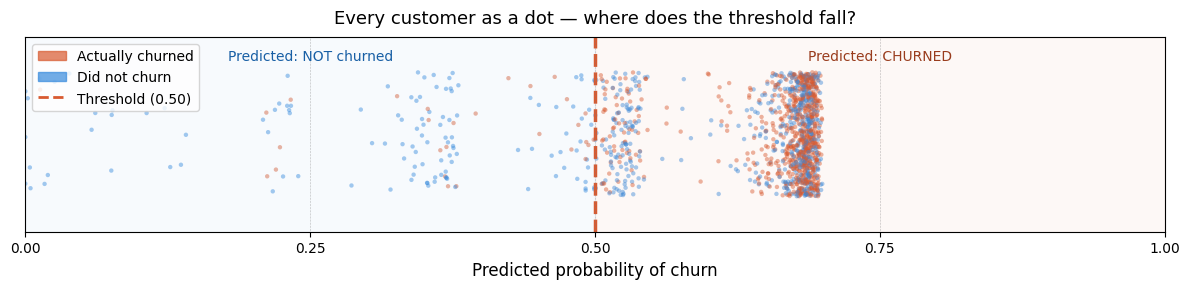

# Discussion
There's a lot going on here! I'll try to make sense of it with a short discussion based on the questions in the module.

1. What threshold did you choose and why?

The bootom line here is that our model isn't great. Looking at the figure immediately above, nothing has a predicted churn above a threshold of about 0.7. Thus anything even close to that isn't going to have sufficient recall to be helpful. Given a contact cost of $10, the best threshold regardless of coupon effectiveness is 0.15. This is based solely on financial performance, whichh is exactly the reason we're in business. So set aside all of the statistics and go with 0.15.

This doesn't mean that the statistics are useless. They go a long way to indicating how poorly our model performs.

2. What trade-off did you observe between recall and false positive rate?

We want a high recall and a low false positive rate. Unfortunately as we increase the threshold, both go down. It's a tradeoff. That's where the business scenario is illustrative because it presents a cost for each and allows us to balance them.

3. How does your chosen threshold compare to the default 0.5?

We're much lower. The 1:20 cost to savings sets us up to want a very high recall and precision isn't as critical.

4. Would you recommend this model for deployment?

In the absense of any other model or any indication that we're going to make an effort to improve it, I would recommend it for deployment - there is a theoretical net positive value at all reasonable coupon response rates. BUT, given what we know about how poor the model is and that there is a good chance that we can improve it I would recommend postponing implementation. A few hours spent building a better model will yield better results and prevent customer confusion and over-engagement.

5. If the cost of contacting customers increased, how would your decision change.

I actually ran the calculations for $50 (see above). There is still a possible positive financial result but only at unreasonably high levels of coupon success. This actually makes the picture much more clear. We need a better model.